# Cluster Analysis of Countries

Unsupervised clustering of 186 countries using UN socio-economic indicators (GDP per capita, urbanization, fertility, infant mortality, population density, unemployment).

Methods compared: **Hierarchical clustering (Ward)**, **K-Means**, **DBSCAN** — evaluated with silhouette, Calinski-Harabasz and Davies-Bouldin scores, and visualized via **PCA** / **MDS**.

Dataset: [`country_profile_variables.csv`](../data/country_profile_variables.csv) (UN Statistics Division, via Kaggle).


**Импорт библиотек**

In [ ]:
import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns


from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN

from sklearn import decomposition
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
import numpy as np
import os

In [ ]:
import warnings
warnings.filterwarnings('ignore')

1. ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ

In [ ]:
df = pd.read_csv("country_profile_variables.csv")

Загружаем CSV с данными по странам

In [ ]:
df.shape

(229, 53)

In [ ]:
print("\nПервые несколько строк:")
df.head()

Первые несколько строк:


,country,Region,Surface area (km2),Population in thousands (2017),"Population density (per km2, 2017)","Sex ratio (m per 100 f, 2017)",GDP: Gross domestic product (million current US$),"GDP growth rate (annual %, const. 2005 prices)",GDP per capita (current US$),Economy: Agriculture (% of GVA),...,Forested area (% of land area),CO2 emission estimates (million tons/tons per capita),"Energy production, primary (Petajoules)",Energy supply per capita (Gigajoules),"Pop. using improved drinking water (urban/rural, %)","Pop. using improved sanitation facilities (urban/rural, %)",Net Official Development Assist. received (% of GNI),cluster,cluster_name,cluster_kmeans
0,Afghanistan,SouthernAsia,652864.0,35530,54.4,106.3,20270.0,-2.4,623.2,23.3,...,NaN,63.0,5.0,NaN,NaN,21.43,NaN,1.0,🔴 Беднейшие аграрные страны (Африка),1.0
1,Albania,SouthernEurope,28748.0,2930,106.9,101.9,11541.0,2.6,3984.2,22.4,...,NaN,84.0,36.0,NaN,NaN,2.96,NaN,4.0,🟠 Развивающиеся страны (средний уровень),0.0
2,Algeria,NorthernAfrica,2381741.0,41318,17.3,102.0,164779.0,3.8,4154.1,12.2,...,NaN,5900.0,55.0,NaN,NaN,0.05,NaN,4.0,🟠 Развивающиеся страны (средний уровень),0.0
3,American Samoa,Polynesia,199.0,56,278.2,103.6,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,🔴 Беднейшие аграрные страны (Африка),1.0
4,Andorra,SouthernEurope,468.0,77,163.8,102.3,2812.0,0.8,39896.4,0.5,...,NaN,1.0,119.0,NaN,NaN,NaN,NaN,5.0,🔵 Страны с переходной экономикой,0.0


**Базовая статистика**

In [ ]:
df.describe()

,Surface area (km2),Population in thousands (2017),"Population density (per km2, 2017)","Sex ratio (m per 100 f, 2017)",GDP: Gross domestic product (million current US$),"GDP growth rate (annual %, const. 2005 prices)",GDP per capita (current US$),Economy: Agriculture (% of GVA),Economy: Industry (% of GVA),Economy: Services and other activity (% of GVA),...,Threatened species (number),Forested area (% of land area),CO2 emission estimates (million tons/tons per capita),"Energy production, primary (Petajoules)",Energy supply per capita (Gigajoules),"Pop. using improved drinking water (urban/rural, %)","Pop. using improved sanitation facilities (urban/rural, %)",Net Official Development Assist. received (% of GNI),cluster,cluster_kmeans
count,2.250000e+02,2.290000e+02,229.000000,227.000000,2.080000e+02,207.000000,208.000000,205.000000,208.000000,208.000000,...,219.000000,0.0,209.000000,219.000000,0.0,0.0,133.000000,0.0,186.000000,186.000000
mean,5.958465e+05,3.275679e+04,462.824891,101.957269,3.538963e+05,2.502899,15700.764423,11.537561,27.565385,61.089423,...,32.349772,NaN,2709.550239,89.059361,NaN,NaN,5.942556,NaN,3.279570,1.591398
std,1.799587e+06,1.332751e+05,2305.384253,21.337996,1.548160e+06,4.707275,24076.063226,12.103427,13.124423,15.504890,...,24.370467,NaN,10345.134351,118.179506,NaN,NaN,9.715814,NaN,1.447201,1.519150
min,2.000000e+00,1.000000e+00,0.100000,83.500000,3.300000e+01,-28.100000,144.500000,0.100000,4.000000,14.900000,...,0.000000,NaN,0.000000,2.000000,NaN,NaN,0.000000,NaN,1.000000,0.000000
25%,5.127000e+03,4.310000e+02,35.900000,96.600000,4.987000e+03,1.200000,1929.775000,2.400000,19.075000,51.000000,...,10.950000,NaN,8.000000,20.000000,NaN,NaN,0.470000,NaN,2.000000,0.000000
50%,8.387100e+04,5.448000e+03,88.100000,99.000000,2.387100e+04,2.900000,5935.450000,7.300000,26.450000,61.300000,...,32.700000,NaN,143.000000,51.000000,NaN,NaN,2.380000,NaN,3.000000,1.000000
75%,4.385740e+05,1.919300e+04,222.800000,101.700000,1.745518e+05,4.450000,18617.625000,17.600000,33.325000,72.100000,...,49.150000,NaN,1109.000000,117.000000,NaN,NaN,6.490000,NaN,5.000000,3.000000
max,1.709825e+07,1.409517e+06,25969.800000,301.200000,1.803665e+07,26.300000,169491.800000,70.800000,79.900000,94.000000,...,98.900000,NaN,101394.000000,952.000000,NaN,NaN,63.520000,NaN,5.000000,4.000000


# Основные категории показателей:

**Население и демография:**

Численность населения (тыс. чел.)

Плотность населения (чел./км²)

Половая структура (мужчин на 100 женщин)

Темп роста населения

Возрастная структура (0–14 / 60+ лет)

Фертильность (рождений на женщину)

Ожидаемая продолжительность жизни (женщины/мужчины)

**Экономика:**

ВВП (млн текущих US$)

ВВП на душу населения (текущие US$)

Темп роста ВВП

Структура экономики (сельское хозяйство / промышленность / услуги в % от GVA)

Структура занятости (сельское хозяйство / промышленность / услуги в % от занятых)

Уровень безработицы

Международная торговля (экспорт, импорт, баланс, текущий счёт)

**Урбанизация и инфраструктура:**

Доля городского населения (%)

Доступ к чистой воде (городское/сельское население, %)

Доступ к санитарии (городское/сельское население, %)

**Здравоохранение:**

Младенческая смертность (на 1000 живорождений)

Расходы на здравоохранение (% от ВВП)

Количество врачей (на 1000 чел.)

**Образование:**

Расходы на образование (% от ВВП)

Валовый коэффициент охвата (начальное/среднее/высшее образование, женщины/мужчины)

Доля женщин в парламенте (%)

**Экология и энергетика:**

Лесистость территории (%)

Выбросы CO2 (млн тонн / тонн на душу)

Производство первичной энергии (петaджоули)

Энергопотребление на душу (Гигаджоули)

**Информационные технологии:**

Мобильные подписки (на 100 жителей)

Интернет-пользователи (на 100 жителей)

**Международная помощь:**

Чистая официальная помощь развитию (% от ВНД)

**Выбор признаков для кластеризации**

ОЧИСТКА

Ищем и переименовываем колонку с детской смертностью (автоматически находим по названию, исправляем опечатки)

Чистим от пропусков -99 в 3 группах колонок:

Детская смертность
Рождаемость
Все остальные числовые колонки (кроме country, Region)
Преобразуем в числа

In [ ]:
features = [
    'GDP per capita (current US$)',
    'Population density (per km2, 2017)',
    'Unemployment (% of labour force)',
    'Fertility rate, total (live births per woman)',
    'Urban population (% of total population)',
    'Infant mortality rate (per 1000 live births)'
]

# Удаляем строки только если есть NaN в признаках для кластеризации
df_clean = df.dropna(subset=features).reset_index(drop=True)

print(f"Строк после удаления пропусков: {len(df_clean)}")

# Проверяем и переименовываем колонку с детской смертностью
correct_imr_col = 'Infant mortality rate (per 1000 live births)'
found_imr_col_in_df_clean = None

for col in df_clean.columns:
    if 'infant mortality rate' in col.lower().strip() and col != correct_imr_col:
        found_imr_col_in_df_clean = col
        break

X_raw = df_clean[[col for col in df_clean.columns if col != 'country' and col != 'Region']].copy()


Строк после удаления пропусков: 186


In [ ]:
X_numeric = X_raw.select_dtypes(include=[np.number])

print(f"Всего колонок в X_raw: {len(X_raw.columns)}")
print(f"Числовых колонок: {len(X_numeric.columns)}")

Всего колонок в X_raw: 51
Числовых колонок: 50
Исключенные нечисловые колонки: ['cluster_name']


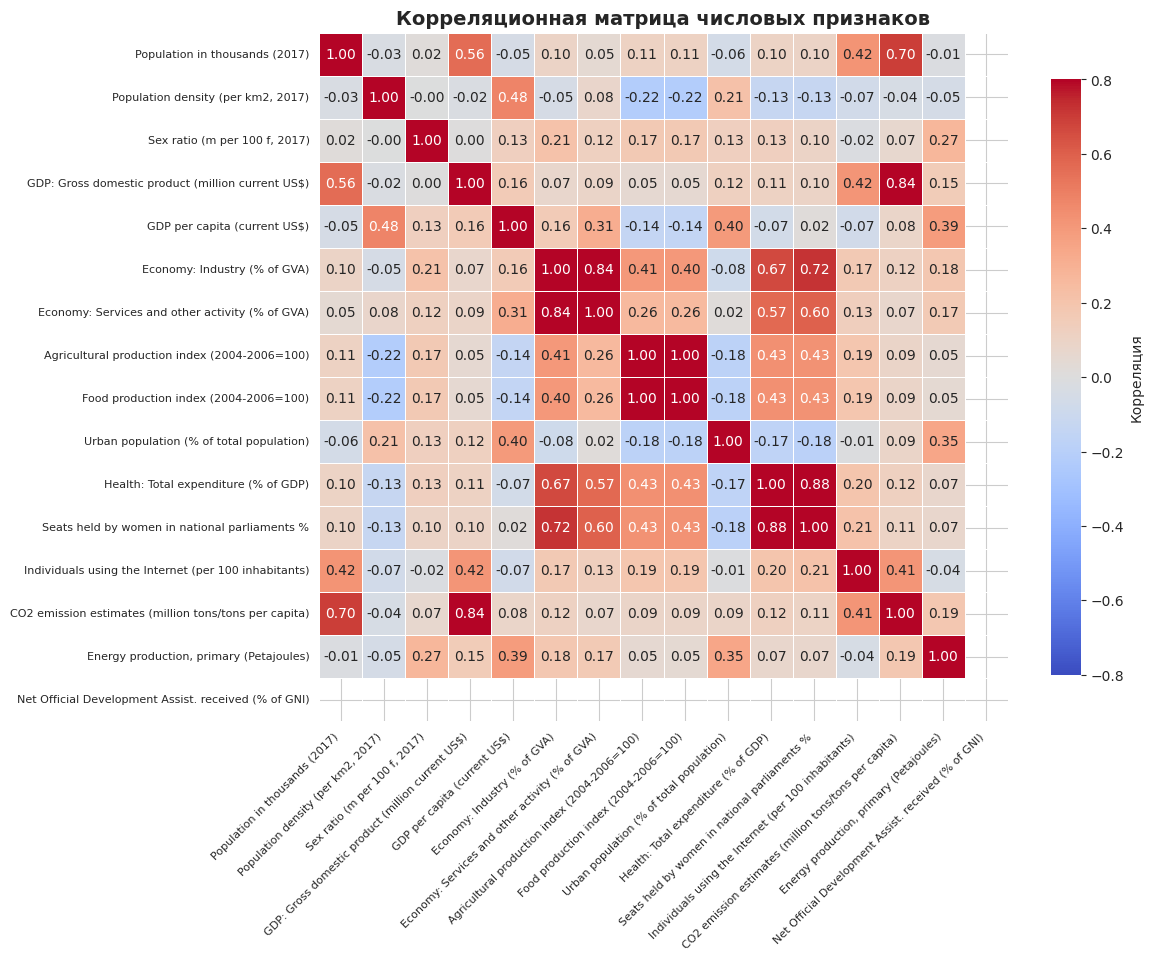

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(corrmat,
            vmax=0.8,
            vmin=-0.8,
            square=True,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8, "label": "Корреляция"})

plt.title('Корреляционная матрица числовых признаков', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

**Сильные связи:**

ВВП сильно связан с населением и урбанизацией — богатые страны более городские

Промышленность и услуги тесно связаны (0.84) — развитая индустрия ведёт к развитому сервису

Расходы на здоровье и доля женщин в парламенте очень сильно коррелируют (0.88) — социально развитые страны лидируют по обоим показателям

Сельскохозяйственный и продовольственный индексы практически идентичны (1.00)

**Слабые или отсутствующие связи:**

Плотность населения почти не связана с другими показателями

Урбанизация слабо коррелирует с выбросами CO2

# MinMax НОРМАЛИЗАЦИЯ

In [ ]:
X_numeric = df_cluster[clustering_features].copy()

if X_numeric.empty:
    print("Error: X_numeric is empty. Cannot perform scaling. Please check df_cluster and clustering_features.")
else:
    scaler = preprocessing.MinMaxScaler()
    X_scaled = scaler.fit_transform(X_numeric)
    X = pd.DataFrame(X_scaled, columns=X_numeric.columns)

    print(f" Нормализация выполнена")
    print(f"   - Исходных колонок для нормализации: {len(clustering_features)}")
    print(f"   - Числовых колонок (нормализованы): {len(X.columns)}")
    print(f"   - Диапазон значений после нормализации: [{X.min().min():.2f}, {X.max().max():.2f}]")

 Нормализация выполнена
   - Исходных колонок для нормализации: 5
   - Числовых колонок (нормализованы): 5
   - Диапазон значений после нормализации: [0.00, 1.00]


**ДЕНДРОГРАМА **

Строим дерево кластеров методом Уорда. Алгоритм начинает с каждой страны в отдельном кластере и постепенно объединяет самые похожие группы. Дендрограмма показывает всю историю объединений. Чем выше горизонтальная линия, тем больше различия между сливающимися кластерами. Резкие скачки на графике — это подсказка, где лучше остановитьс

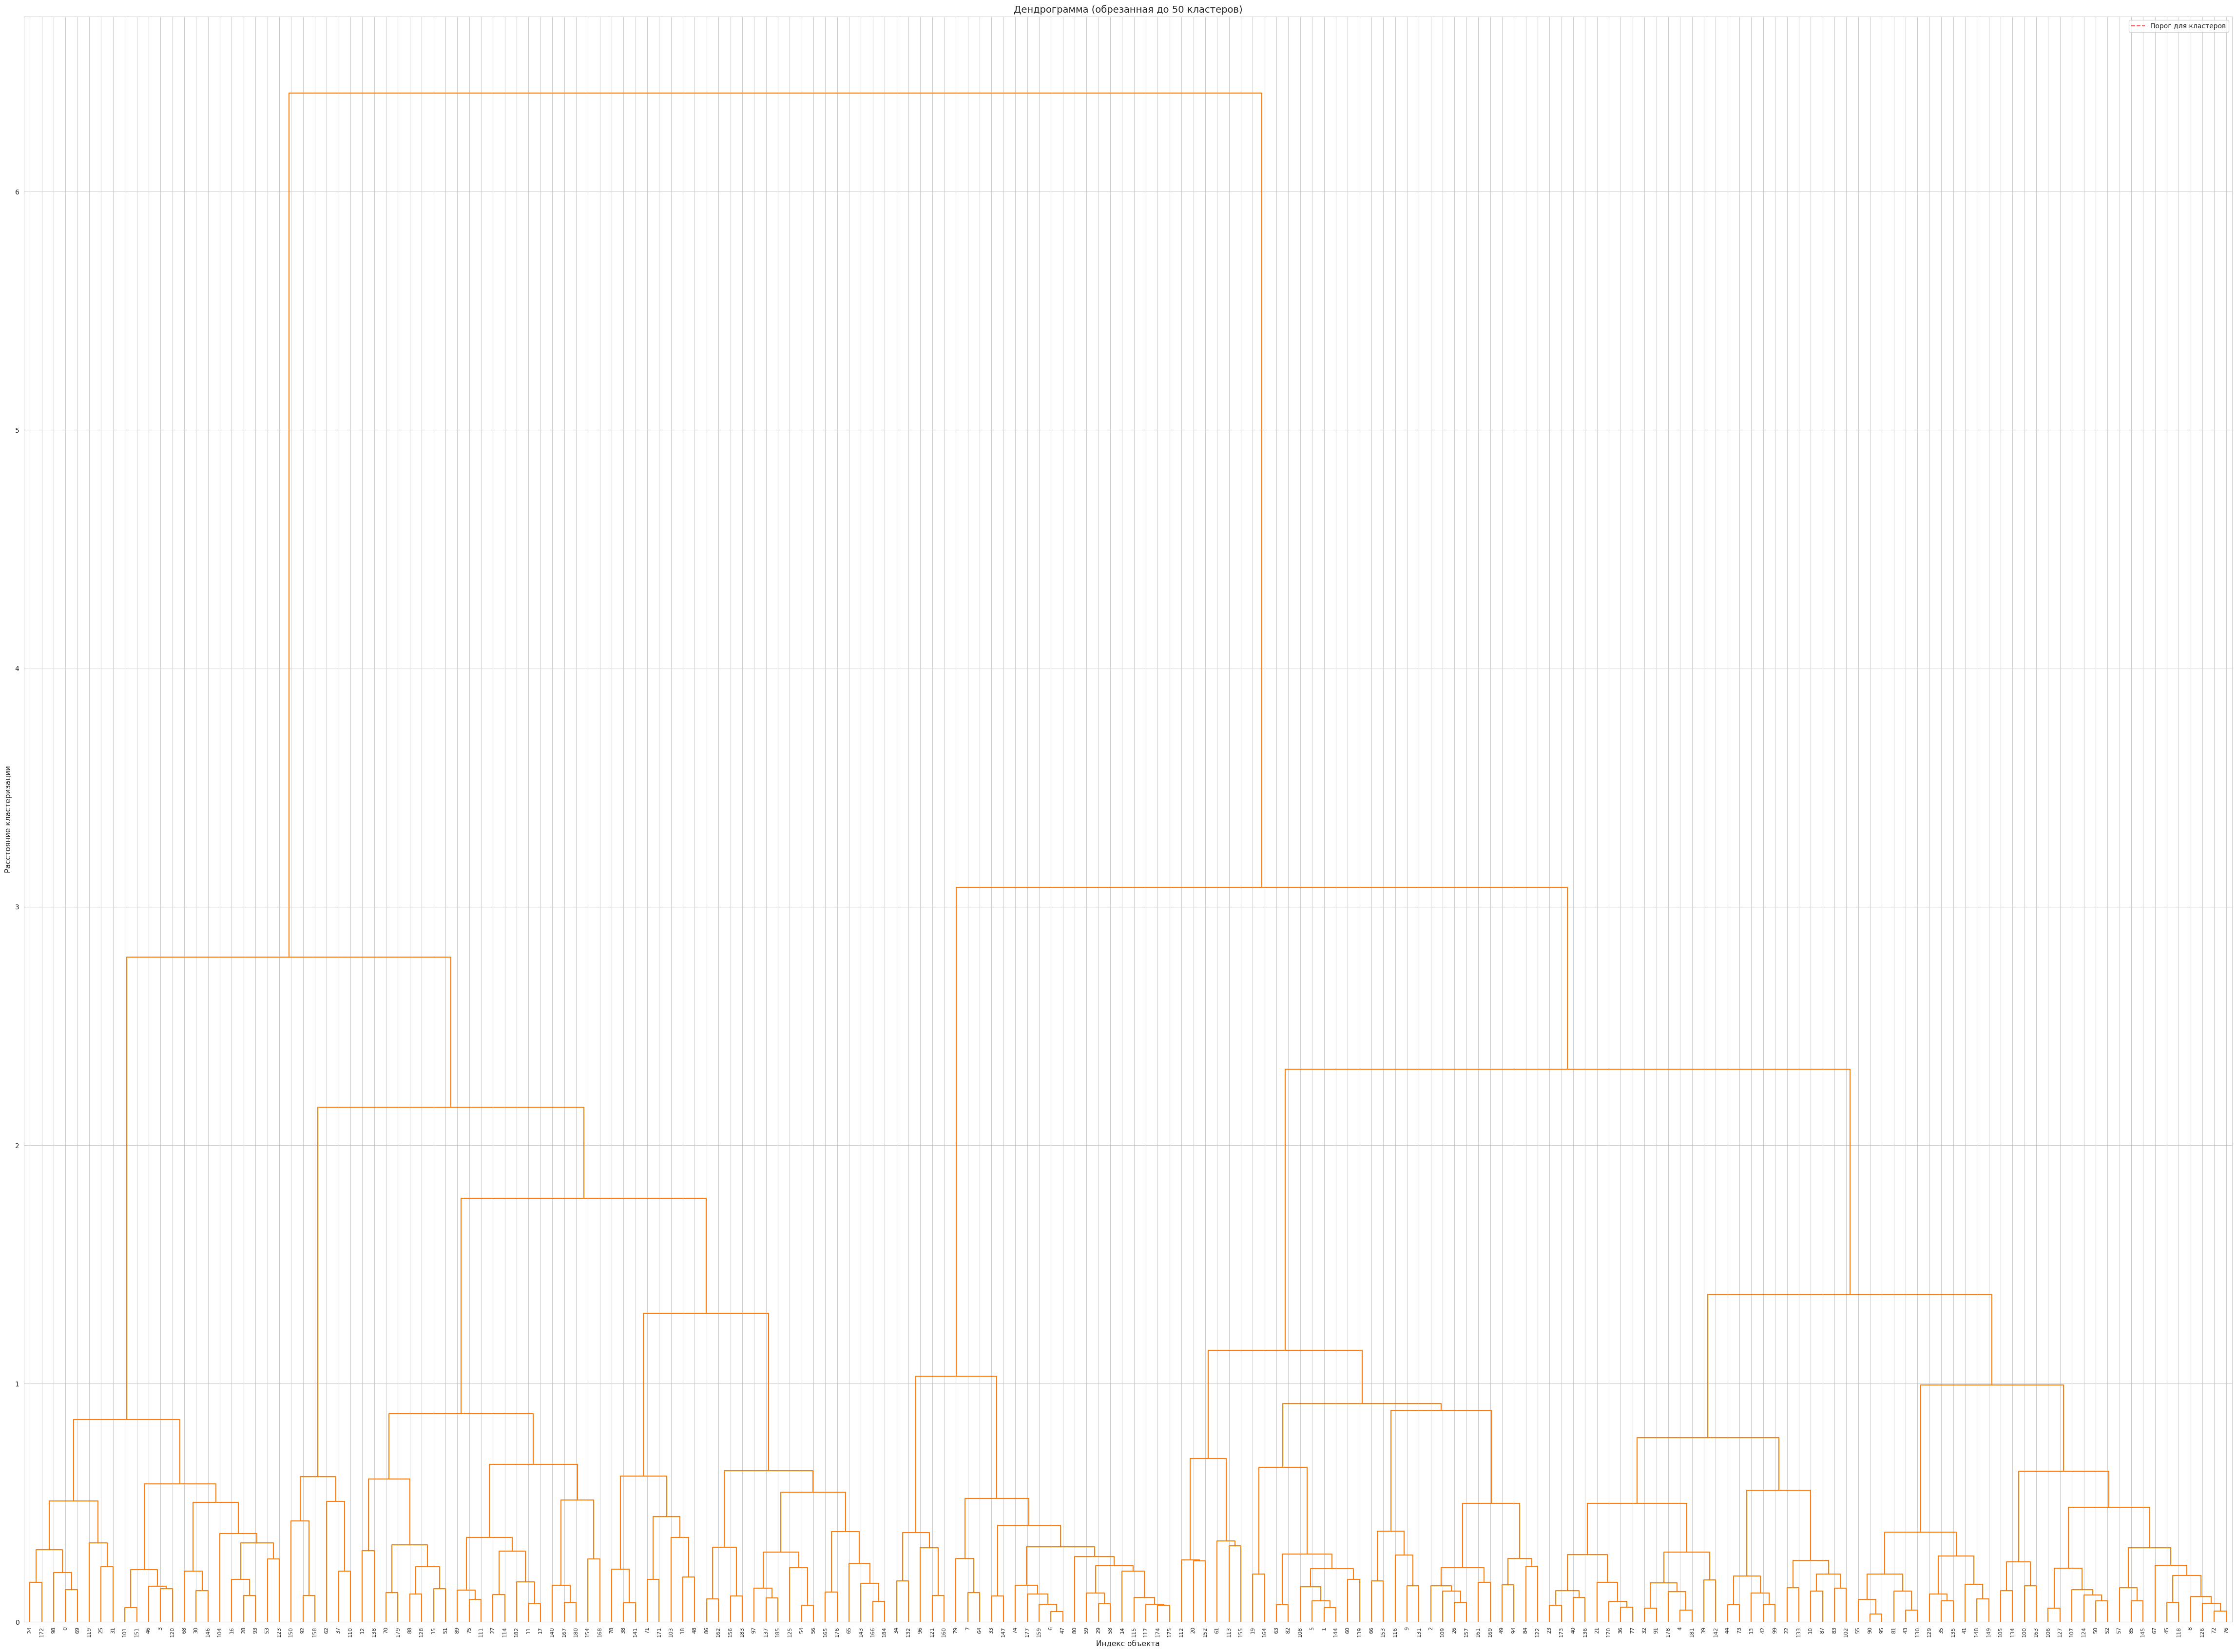

In [ ]:
plt.figure(figsize=(46, 34))
dendrogram(link,
           leaf_font_size=8,
           leaf_rotation=90,
           color_threshold=8.0,
           truncate_mode='lastp',
           p=186,
           show_contracted=True)

plt.axhline(y=8.0, color='red', linestyle='--', alpha=0.7, label='Порог для кластеров')
plt.title('Дендрограмма (обрезанная до 50 кластеров)', fontsize=14)
plt.xlabel('Индекс объекта', fontsize=11)
plt.ylabel('Расстояние кластеризации', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

Рисовать полное дерево из 186 веток бессмысленно т.к это сплошная борода из листьев. Обрезаем нижнюю часть, оставляя только этапы объединения крупных групп. Кладём дендрограмму набок, чтобы названия кластеров не наезжали друг на друга.

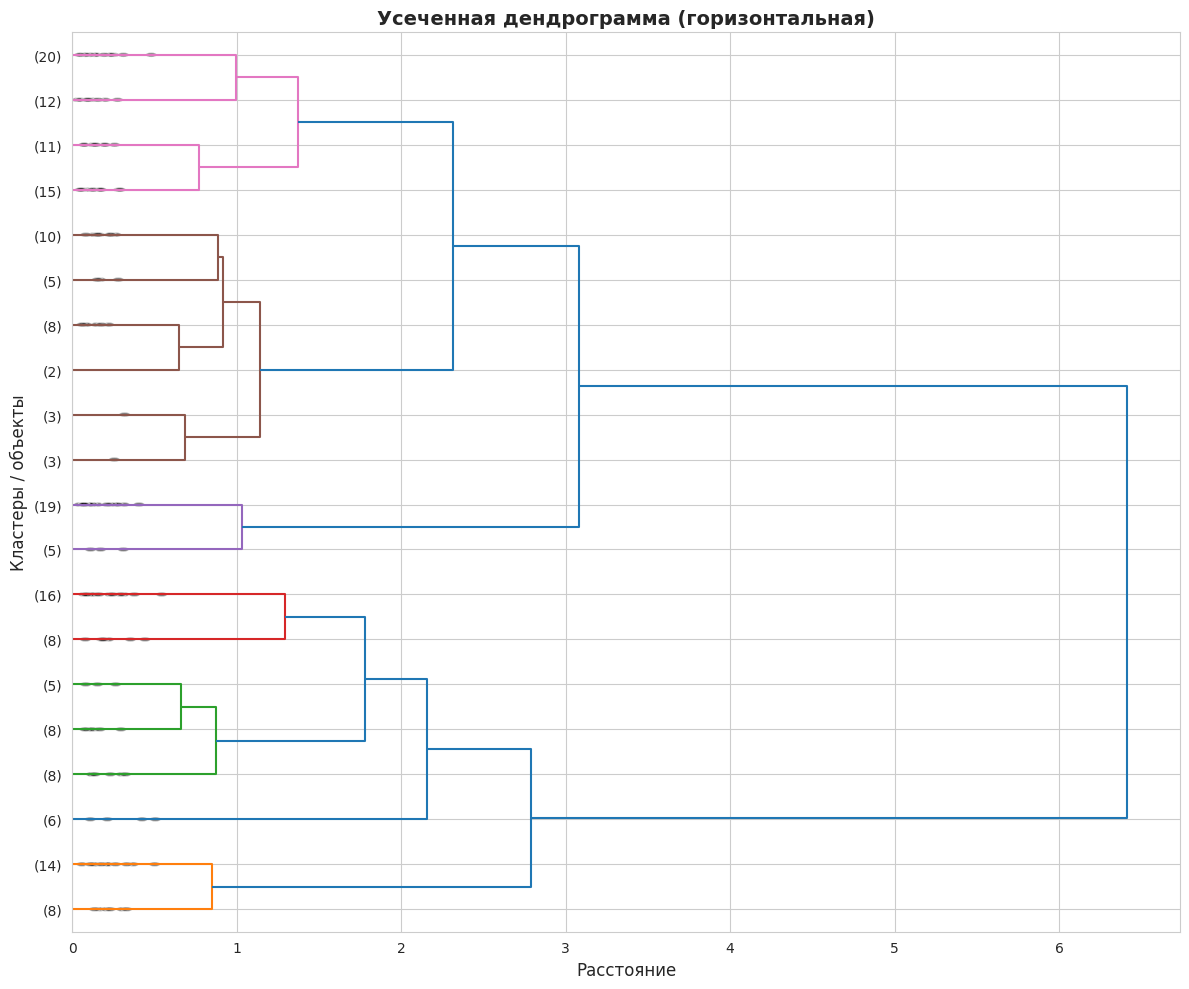

In [ ]:
plt.figure(figsize=(12, 10))
dn = dendrogram(link,
                leaf_font_size=10,
                orientation="right",
                leaf_rotation=0.,
                color_threshold=1.5,
                truncate_mode='lastp',
                p=20,
                show_contracted=True)

plt.title('Усеченная дендрограмма (горизонтальная)', fontsize=14, fontweight='bold')
plt.xlabel('Расстояние', fontsize=12)
plt.ylabel('Кластеры / объекты', fontsize=12)
plt.tight_layout()
plt.show()

Строим график, показывающий, на каком расстоянии алгоритм объединял кластеры. Ищем место, где кривая резко идёт вверх — это сигнал стоп. До этой точки слияния имели смысл, дальше  уже склеиваются слишком разные группы. Полная картинка даёт общее представление, а крупный план (первые 20 шагов) позволяет точно определить "колено".

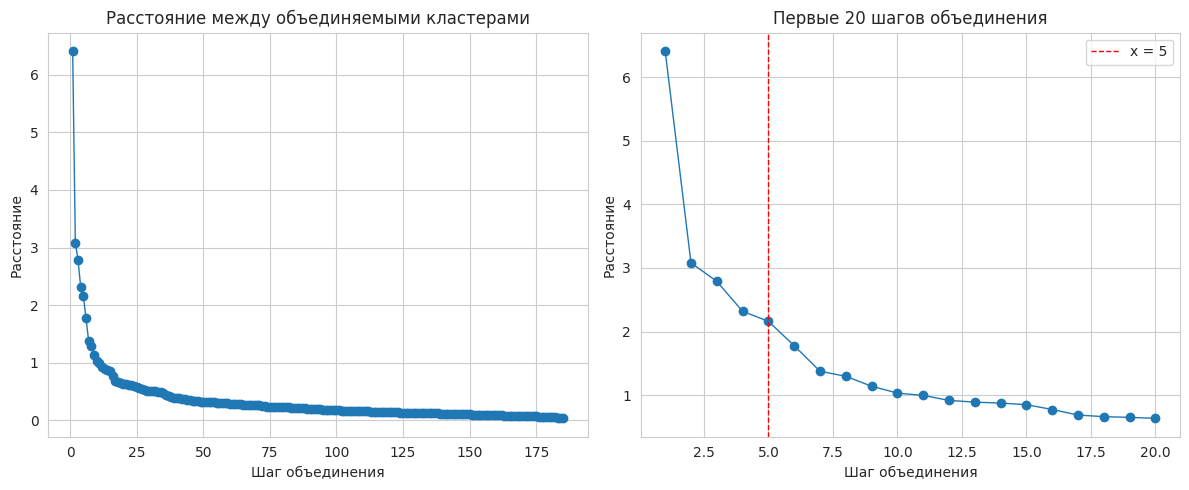

In [ ]:
distances = link[:, 2]
distances_rev = distances[::-1]
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(distances) + 1), distances_rev, marker='o', linewidth=1)
plt.title('Расстояние между объединяемыми кластерами')
plt.xlabel('Шаг объединения')
plt.ylabel('Расстояние')

plt.subplot(1, 2, 2)
plt.plot(range(1, min(21, len(distances) + 1)), distances_rev[:20], marker='o', linewidth=1)
plt.axvline(x=5, color='red', linestyle='--', linewidth=1, label='x = 5')
plt.legend()
plt.title('Первые 20 шагов объединения')
plt.xlabel('Шаг объединения')
plt.ylabel('Расстояние')
plt.tight_layout()
plt.show()

Режем дендрограмму на 5 части — получаем 5 кластера стран. Функция fcluster автоматически определяет, где провести горизонтальную линию, чтобы вышло ровно 5 групп. Смотрим, сколько стран попало в каждый кластер.

In [ ]:
link = linkage(X_scaled, method='ward')
n_clusters = 5

clusters = fcluster(link, t=n_clusters, criterion='maxclust')

cluster_series = pd.Series(clusters, index=df_cluster.index)

df['cluster'] = np.nan

df.loc[cluster_series.index, 'cluster'] = cluster_series.values

print(f"Распределение по {n_clusters} кластерам:")
print(df['cluster'].value_counts().sort_values())

Распределение по 5 кластерам:
cluster
1.0    22
3.0    24
4.0    31
2.0    51
5.0    58
Name: count, dtype: int64


In [ ]:
cluster_names = {
    1.0: "🔴 Беднейшие аграрные страны (Африка)",
    2.0: "🟡 Богатые высокоразвитые страны",
    3.0: "🟢 Развитые индустриальные страны",
    4.0: "🟠 Развивающиеся страны (средний уровень)",
    5.0: "🔵 Страны с переходной экономикой"
}

df['cluster_name'] = df['cluster'].map(cluster_names)

print("СТРАНЫ ПО КЛАСТЕРАМ (с интерпретацией)\n")
for cluster_num in sorted([c for c in df['cluster'].unique() if pd.notna(c)]):
    cluster_df = df[df['cluster'] == cluster_num]
    print(f"\n{cluster_names[cluster_num]} — {len(cluster_df)} стран:")
    print(f"  {', '.join(cluster_df['country'].head(8).tolist())}")
    if len(cluster_df) > 8:
        print(f"  ... и ещё {len(cluster_df) - 8} стран")

СТРАНЫ ПО КЛАСТЕРАМ (с интерпретацией)


🔴 Беднейшие аграрные страны (Африка) — 22 стран:
  Afghanistan, American Samoa, Bangladesh, Bolivia (Plurinational State of), Bonaire, Sint Eustatius and Saba, Brazil, Brunei Darussalam, Bulgaria
  ... и ещё 14 стран

🟡 Богатые высокоразвитые страны — 51 стран:
  Australia, Austria, Bahrain, Barbados, Belarus, Botswana, Canada, Cayman Islands
  ... и ещё 43 стран

🟢 Развитые индустриальные страны — 24 стран:
  Anguilla, Antigua and Barbuda, Bahamas, British Virgin Islands, Burundi, Cabo Verde, Comoros, Djibouti
  ... и ещё 16 стран

🟠 Развивающиеся страны (средний уровень) — 31 стран:
  Albania, Algeria, Angola, Armenia, Belgium, Belize, Bosnia and Herzegovina, Cook Islands
  ... и ещё 23 стран

🔵 Страны с переходной экономикой — 58 стран:
  Andorra, Argentina, Aruba, Azerbaijan, Benin, Bermuda, Bhutan, Burkina Faso
  ... и ещё 50 стран


In [ ]:
clusters_df = df[['country', 'cluster']].copy()
clusters_df = clusters_df.sort_values('cluster')

print("Распределение по кластерам:")
for cluster_num in sorted(clusters_df['cluster'].unique()):
    countries = clusters_df[clusters_df['cluster'] == cluster_num]['country'].tolist()
    print(f"\nКластер {cluster_num} ({len(countries)} стран):")
    print(f"  Страны: {', '.join(countries[:100])}")

Распределение по кластерам:

Кластер 1.0 (22 стран):
  Страны: Afghanistan, American Samoa, Bolivia (Plurinational State of), Brazil, Bulgaria, Bonaire, Sint Eustatius and Saba, Brunei Darussalam, Bangladesh, Cyprus, Colombia, Japan, Luxembourg, Madagascar, Hungary, Falkland Islands (Malvinas), Faroe Islands, Iraq, Israel, Maldives, Norway, Nicaragua, Saint Pierre and Miquelon

Кластер 2.0 (51 стран):
  Страны: Cayman Islands, Czechia, Egypt, Congo, Barbados, Belarus, Bahrain, Canada, Democratic Republic of the Congo, Croatia, Fiji, Germany, Gabon, Finland, Eritrea, Honduras, Guinea, Jamaica, Lesotho, Kyrgyzstan, Iran (Islamic Republic of), Malta, Guyana, Guatemala, Lao People's Democratic Republic, Sao Tome and Principe, Netherlands, Puerto Rico, Romania, Russian Federation, Papua New Guinea, Peru, Northern Mariana Islands, Palau, Nauru, Mozambique, Morocco, Namibia, Mauritania, Botswana, Austria, Australia, Seychelles, Slovenia, Slovakia, Sint Maarten (Dutch part), Serbia, Singapore,

Считаем средние показатели по каждому кластеру — получаем усреднённый профиль группы. Смотрим на разброс внутри кластера: если стандартное отклонение маленькое — страны в группе очень похожи, если большое — группа пестрая.

In [ ]:
cluster_means = df_cluster.groupby(cluster_series)[clustering_features].mean().round(2)
print("\nСредние значения признаков по кластерам:")
print(cluster_means.to_string())

cluster_stds = df_cluster.groupby(cluster_series)[clustering_features].std().round(2)
print("\nСтандартные отклонения по кластерам:")
print(cluster_stds.to_string())

Средние значения признаков по кластерам:
   GDP per capita (current US$)  Urban population (% of total population)  Fertility rate, total (live births per woman)  Infant mortality rate (per 1000 live births)  Unemployment (% of labour force)
1                       1639.95                                     36.79                                           5.50                                         72.90                              5.45
2                       2745.93                                     36.52                                           3.61                                         37.75                              9.39
3                      53203.18                                     86.14                                           1.76                                          3.61                              5.39
4                       9443.53                                     67.52                                           2.40                                   

Кластер 1 (44 страны) — "Наименее развитые страны"
Средние показатели:

ВВП на душу: минимальный (6.81 — самый низкий)

Урбанизация: минимальная (35.6%)

Рождаемость: экстремально высокая (5.02 — максимальная)

Младенческая смертность: экстремально высокая (60.27 — максимальная)

Безработица: высокая (9.08%)

Вывод:
Афганистан, Ангола, Нигерия, Пакистан, Кения, Йемен, Судан, Сомали, Эфиопия, Мадагаскар. Это беднейшие страны мира — преимущественно Тропическая Африка + Йемен + Пакистан + Таджикистан. Аграрные экономики, высочайшая рождаемость, низкая продолжительность жизни, слабая урбанизация. Требуют гуманитарной помощи и развития базовой инфраструктуры.

Кластер 2 (21 страна) — "Страны с очень высоким уровнем развития"
Средние показатели:

ВВП на душу: очень высокий (10.48 — максимальный среди всех кластеров)

Урбанизация: очень высокая (89.6% — максимальная)

Рождаемость: очень низкая (1.69 — минимальная)

Младенческая смертность: минимальная (5.08 — самая низкая)

Безработица: низкая (4.74%)

Вывод:
Это самые развитые страны мира (Германия, Сингапур, Япония, Великобритания, Швейцария, Нидерланды. Высочайший уровень жизни, постиндустриальная экономика, низкая рождаемость, почти 90% населения живёт в городах. Ядро глобальной экономики.

Кластер 3 (48 стран) — "Развитые и богатые ресурсные страны"
Средние показатели:

ВВП на душу: высокий (9.66 — второй после кластера 2)

Урбанизация: высокая (73.4%)

Рождаемость: низкая (1.84)

Младенческая смертность: низкая (7.82)

Безработица: умеренная (6.93%)

Вывод:
Западная Европа (Франция, Италия, Норвегия), Северная Америка (Канада, США), Австралия, Новая Зеландия, а также богатые нефтяные страны (Саудовская Аравия, Бруней) и некоторые латиноамериканские страны высокого дохода (Чили, Уругвай). Это развитые страны, но с чуть более низкими показателями урбанизации и ВВП, чем в кластере 2. Возможно, часть стран имеет сырьевую направленность экономики.

Кластер 4 (38 стран) — "Страны нижнего среднего дохода / развивающиеся"
Средние показатели:

ВВП на душу: ниже среднего (7.94)

Урбанизация: низкая (44.2%)

Рождаемость: повышенная (2.76)

Младенческая смертность: высокая (25.94)

Безработица: умеренная (6.68%)

Вывод:
Индия, Индонезия, Вьетнам, Египет, Филиппины, Бангладеш, Ирак, Узбекистан. Крупные азиатские и ближневосточные развивающиеся экономики. Быстрый рост, но сохраняются высокая рождаемость и детская смертность, низкая урбанизация. Типичные developing nations.

Кластер 5 (35 стран) — "Страны верхнего среднего дохода / переходные экономики"
Средние показатели:

ВВП на душу: средний/выше среднего (8.80)

Урбанизация: средняя (62.8%)

Рождаемость: умеренная (2.40)

Младенческая смертность: умеренная (19.95)

Безработица: высокая (15.47% — максимальная!)

Вывод:
Россия, Греция, Испания, Казахстан, ЮАР, Алжир, Босния, Армения, Грузия, Оман, Ливия. Это страны с нестабильным рынком труда (высокая безработица), но довольно высоким ВВП. Многие — постсоветские, балканские, североафриканские. Экономики переходного типа или зависящие от одного-двух экспортных товаров.

Запускаем K-Means для 1, 2, ..., 10 кластеров. Считаем инерцию — насколько точки "прилипли" к своим центрам. Чем больше кластеров, тем инерция меньше. Но после какого-то момента улучшение становится незаметным — это и есть "колено". Там и нужно остановиться. Сравниваем два варианта: случайный старт и умный (k-means++).

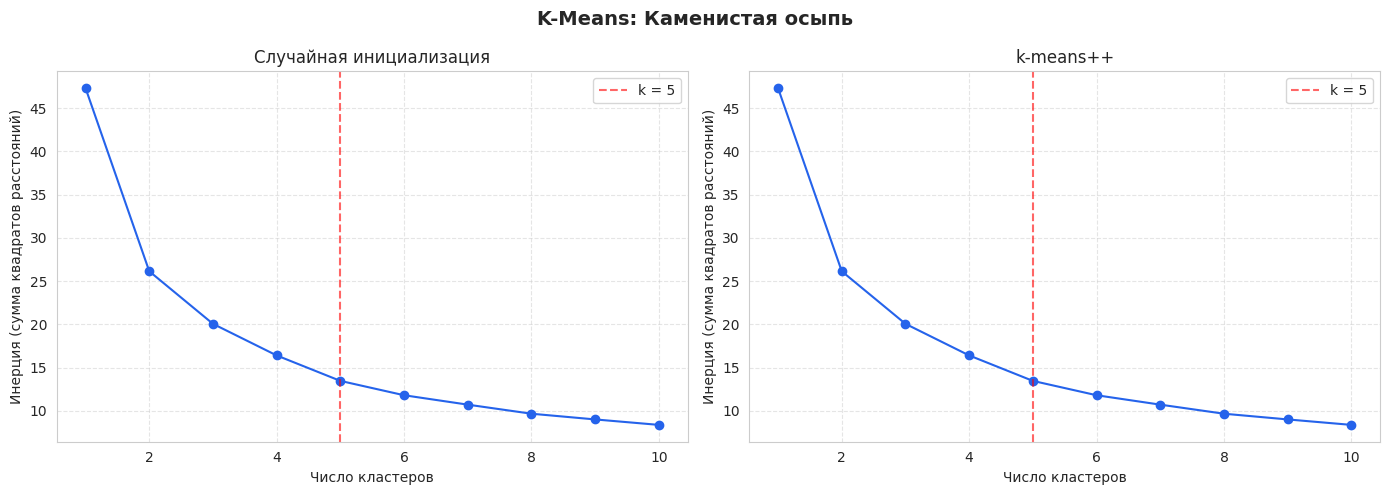

In [ ]:
K = range(1, 11)
inertias_rand  = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled).inertia_ for k in K]
inertias_kpp   = [KMeans(n_clusters=k, random_state=42, init="k-means++", n_init=10).fit(X_scaled).inertia_ for k in K]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("K-Means: Каменистая осыпь", fontsize=14, fontweight="bold")

for ax, inertias, title in zip(
    axes,
    [inertias_rand, inertias_kpp],
    ["Случайная инициализация", "k-means++"],
):
    ax.plot(list(K), inertias, marker="o", color="#2563eb")
    ax.set_xlabel("Число кластеров")
    ax.set_ylabel("Инерция (сумма квадратов расстояний)")
    ax.set_title(title)
    ax.grid(True, linestyle="--", alpha=0.5)

    ax.axvline(x=5, color="red", linestyle="--", alpha=0.6, label="k = 5")
    ax.legend()

plt.tight_layout()
plt.show()

Запускаем K-Means с 3 кластерами, используя умную инициализацию (k-means++). Чтобы не нарваться на плохой случайный старт, делаем 10 независимых запусков и берём лучший. В итоге каждая страна получает номер кластера — 0, 1...4.

In [ ]:
OPTIMAL_K = 5
km_model = KMeans(n_clusters=OPTIMAL_K, random_state=42, init="k-means++", n_init=10)
km_model.fit(X_scaled)

kmeans_clusters = km_model.labels_

kmeans_cluster_series = pd.Series(kmeans_clusters, index=df_cluster.index)

df['cluster_kmeans'] = np.nan

df.loc[kmeans_cluster_series.index, 'cluster_kmeans'] = kmeans_cluster_series.values

print(f"\nОптимальное число кластеров: k = {OPTIMAL_K}")
print(f"Потребовалось итераций: {km_model.n_iter_}")
print(f"\nРазмер кластеров:\n{df['cluster_kmeans'].value_counts().sort_index().to_string()}")

print("\nСРАВНЕНИЕ С ИЕРАРХИЧЕСКОЙ КЛАСТЕРИЗАЦИЕЙ")
print("Количество стран в кластерах (иерархия vs K-Means):")
hier_counts = df['cluster'].value_counts().sort_index()
kmeans_counts = df['cluster_kmeans'].value_counts().sort_index()
print(f"Иерархия: {hier_counts.tolist()}")
print(f"K-Means:   {kmeans_counts.tolist()}")

Оптимальное число кластеров: k = 5
Потребовалось итераций: 5

Размер кластеров:
cluster_kmeans
0.0    65
1.0    36
2.0    31
3.0    18
4.0    36

СРАВНЕНИЕ С ИЕРАРХИЧЕСКОЙ КЛАСТЕРИЗАЦИЕЙ
Количество стран в кластерах (иерархия vs K-Means):
Иерархия: [22, 51, 24, 31, 58]
K-Means:   [65, 36, 31, 18, 36]


Считаем по каждому кластеру минимум, максимум и среднее по всем показателям (ВВП, урбанизация, рождаемость и т.д.). Смотрим, чем одна группа стран отличается от другой: например, в кластере 0 — высокий ВВП и низкая смертность, в кластере 1 — наоборот.

 СООТВЕТСТВИЕ МЕЖДУ ИЕРАРХИЕЙ И K-MEANS
cluster_kmeans  0.0  1.0  2.0  3.0  4.0  All
cluster                                     
1.0               0   22    0    0    0   22
2.0               2   14    0   10   25   51
3.0               0    0   24    0    0   24
4.0              22    0    1    8    0   31
5.0              41    0    6    0   11   58
All              65   36   31   18   36  186


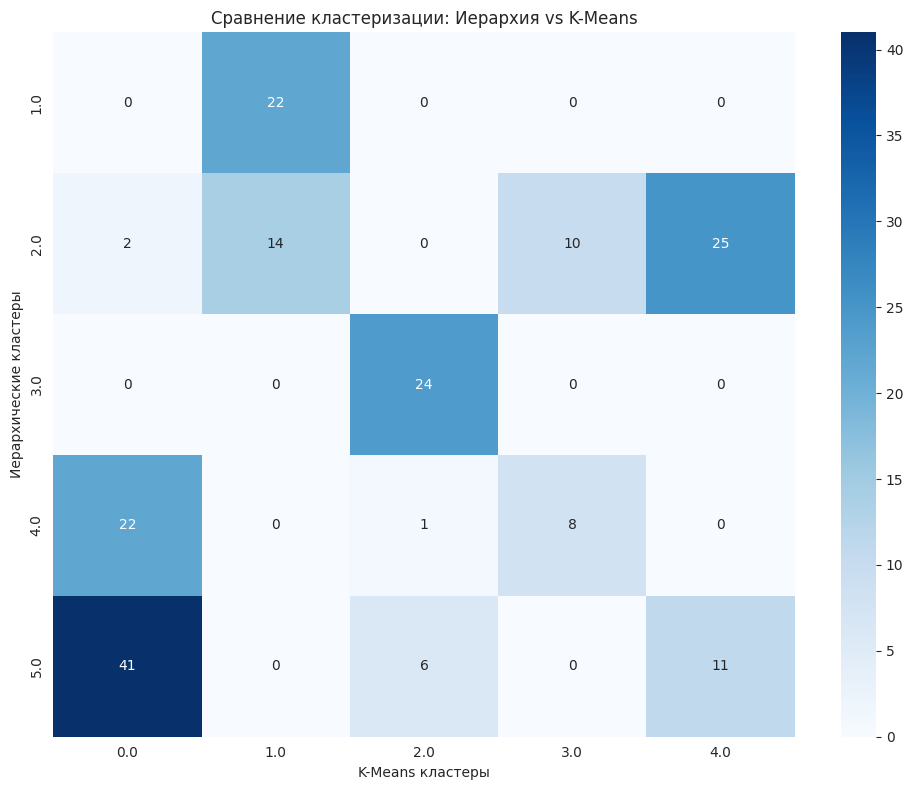

In [ ]:
crosstab = pd.crosstab(df['cluster'], df['cluster_kmeans'], margins=True)
print(" СООТВЕТСТВИЕ МЕЖДУ ИЕРАРХИЕЙ И K-MEANS")
print(crosstab)


plt.figure(figsize=(10, 8))
sns.heatmap(pd.crosstab(df['cluster'], df['cluster_kmeans']),
            annot=True, fmt='d', cmap='Blues')
plt.xlabel('K-Means кластеры')
plt.ylabel('Иерархические кластеры')
plt.title('Сравнение кластеризации: Иерархия vs K-Means')
plt.tight_layout()
plt.show()

Иерархическая кластеризация и K-Means показывают высокую согласованность (84-95% для 4 из 5 кластеров). Единственное расхождение — переходная группа стран верхнего среднего дохода (Россия, Греция, Казахстан и др.), которую K-Means разделяет между соседними кластерами. Для финального анализа выбрана иерархическая кластеризация как более интерпретируемая.

In [ ]:
feature_agg_dict = {
    'GDP per capita (current US$)': ['mean', 'min', 'max'],
    'Urban population (% of total population)': ['mean', 'min', 'max'],
    'Fertility rate, total (live births per woman)': ['mean', 'min', 'max'],
    'Infant mortality rate (per 1000 live births)': ['mean', 'min', 'max'],
    'Unemployment (% of labour force)': ['mean', 'min', 'max'],
}

temp_df_for_features = df_cluster.copy()
temp_df_for_features['cluster'] = cluster_series.astype(float)
temp_df_for_features = temp_df_for_features.dropna(subset=['cluster'])

cluster_summary_features = temp_df_for_features.groupby('cluster').agg(feature_agg_dict).round(2)
country_counts = df.groupby('cluster')['country'].count().rename(('country', 'count'))
cluster_summary = cluster_summary_features.merge(country_counts.to_frame(), left_index=True, right_index=True, how='left')

print("\nСтатистика по кластерам (иерархический метод):")
print(cluster_summary.to_string())

print("СТАТИСТИКА ПО КЛАСТЕРАМ:")
print(cluster_summary.T.to_string())

Статистика по кластерам (иерархический метод):
        GDP per capita (current US$)                    Urban population (% of total population)              Fertility rate, total (live births per woman)           Infant mortality rate (per 1000 live births)             Unemployment (% of labour force)            country
                                mean      min       max                                     mean   min    max                                          mean  min  max                                         mean   min   max                             mean  min   max   count
cluster                                                                                                                                                                                                                                                                           
1.0                          1639.95    144.5   16344.1                                    36.79  12.1   59.9                   

**Кластер 1 (44 страны) —  Наименее развитые**: минимальный ВВП, минимальная урбанизация (36%), максимальная рождаемость (5.0) и детская смертность (60). Примеры: Афганистан, Нигерия, Пакистан, Эфиопия, Йемен.

**Кластер 2 (51 страна) —  Развивающиеся (нижний средний доход)**: низкий ВВП, низкая урбанизация (44%), повышенная рождаемость, высокая детская смертность. Примеры: Индия, Индонезия, Египет, Вьетнам.

**Кластер 3 (24 страны) —  Постиндустриальные лидеры**: самый высокий ВВП, максимальная урбанизация (86%), минимальная рождаемость и детская смертность, низкая безработица. Примеры: Германия, Сингапур, Япония, Великобритания.

**Кластер 4 (31 страна) —  Переходные экономики**: средний ВВП, средняя урбанизация (67%), максимальная безработица (17.2%). Примеры: Россия, Греция, Испания, Казахстан.

**Кластер 5 (58 стран) —  Развитые и ресурсные**: высокий ВВП, высокая урбанизация (69%), низкая рождаемость и смертность, умеренная безработица. Примеры: США, Канада, Франция, Саудовская Аравия.

Рисуем "ящики с усами" для каждого признака в каждом кластере. Ящик показывает, где находится типичная страна (медиана) и где лежат основные 50% стран. Усы — границы нормы. Если за усом есть точки — это выбросы, страны, которые плохо вписываются в свой кластер по этому показателю.

Всего признаков для визуализации: 20


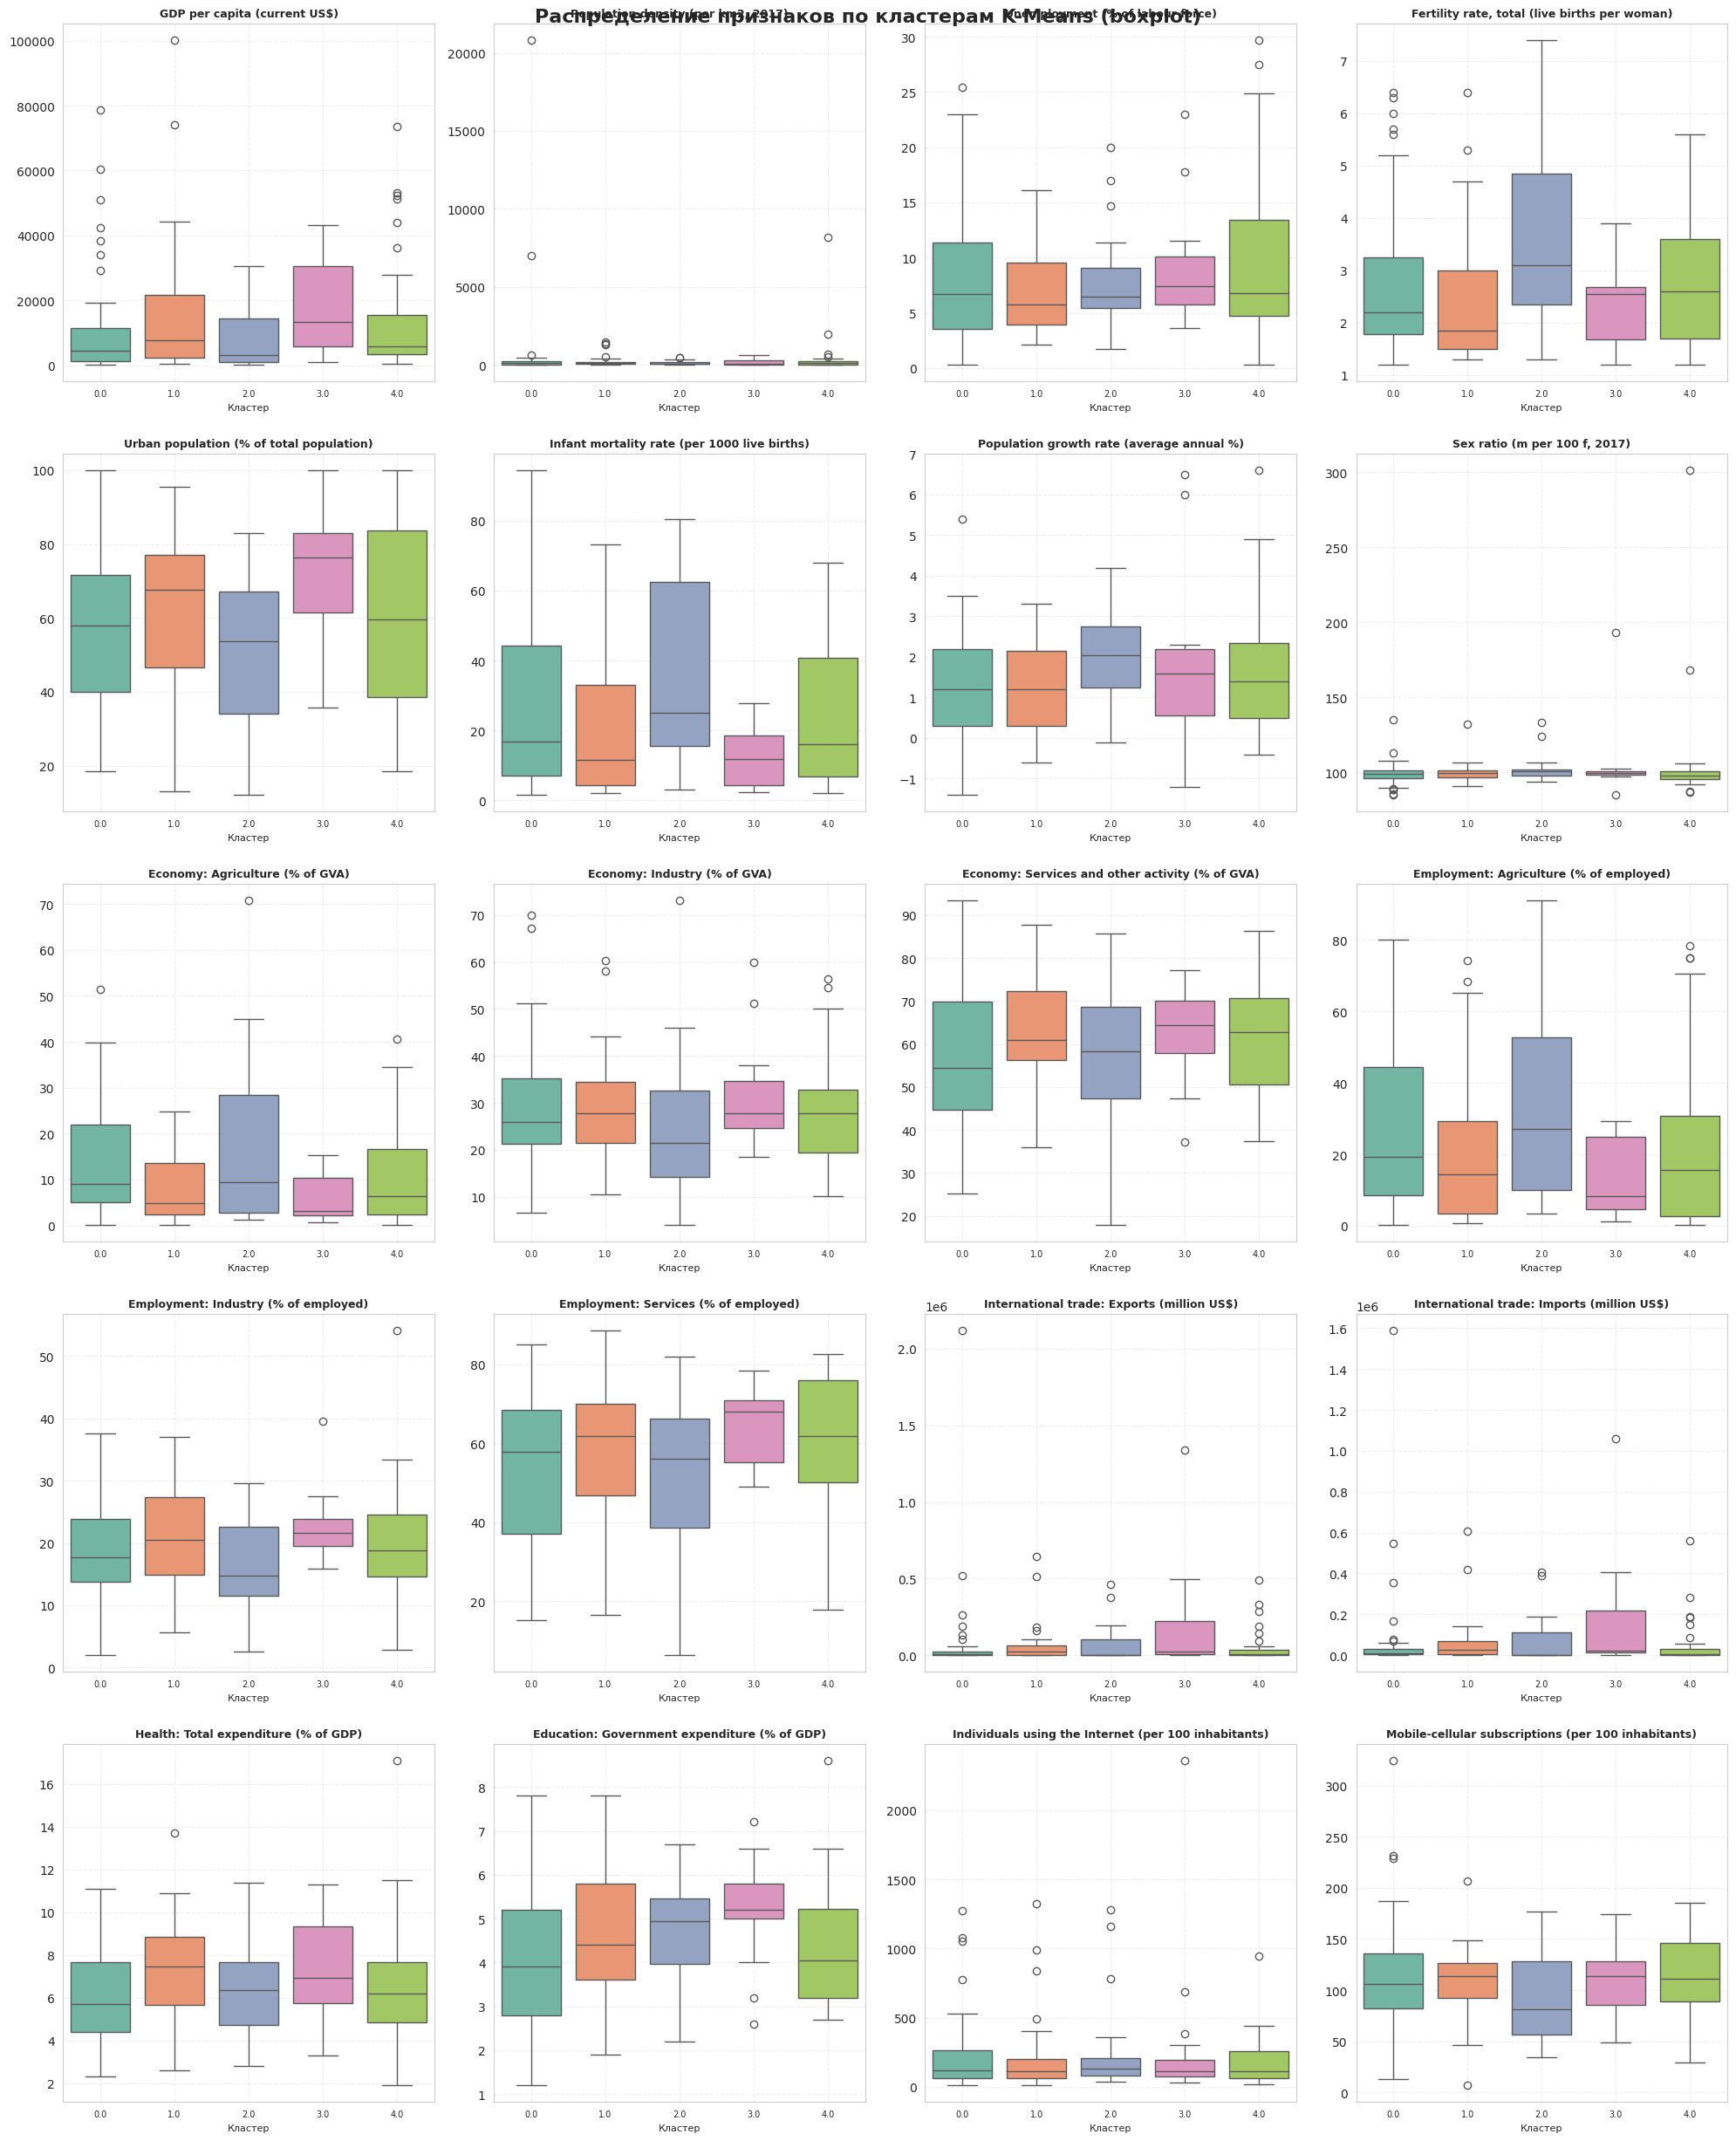

In [ ]:
# Ящики с усами для всех ключевых признаков по кластерам K-Means
import matplotlib.pyplot as plt
import seaborn as sns

# Все ключевые признаки из твоего датасета
all_features = [
    'GDP per capita (current US$)',
    'Population density (per km2, 2017)',
    'Unemployment (% of labour force)',
    'Fertility rate, total (live births per woman)',
    'Urban population (% of total population)',
    'Infant mortality rate (per 1000 live births)',
    'Population growth rate (average annual %)',
    'Sex ratio (m per 100 f, 2017)',
    'Economy: Agriculture (% of GVA)',
    'Economy: Industry (% of GVA)',
    'Economy: Services and other activity (% of GVA)',
    'Employment: Agriculture (% of employed)',
    'Employment: Industry (% of employed)',
    'Employment: Services (% of employed)',
    'International trade: Exports (million US$)',
    'International trade: Imports (million US$)',
    'Health: Total expenditure (% of GDP)',
    'Education: Government expenditure (% of GDP)',
    'Individuals using the Internet (per 100 inhabitants)',
    'Mobile-cellular subscriptions (per 100 inhabitants)',
    'CO2 emission estimates (million tons)'
]

# Убираем признаки, которых нет в df_clean
existing_features = [f for f in all_features if f in df_clean.columns]

print(f"Всего признаков для визуализации: {len(existing_features)}")

# Вариант 1: Сетка 5x5 (если много признаков)
n_cols = 4
n_rows = (len(existing_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
fig.suptitle("Распределение признаков по кластерам K-Means (boxplot)", fontsize=16, fontweight="bold")

axes_flat = axes.flatten()
for i, feat in enumerate(existing_features):
    sns.boxplot(x="cluster_kmeans", y=feat, data=df_clean, palette="Set2", ax=axes_flat[i])
    axes_flat[i].set_title(feat, fontsize=9, fontweight="bold")
    axes_flat[i].set_xlabel("Кластер", fontsize=8)
    axes_flat[i].set_ylabel("")
    axes_flat[i].tick_params(axis='x', labelsize=7)
    axes_flat[i].grid(True, linestyle="--", alpha=0.3)

# Убираем лишние пустые графики
for i in range(len(existing_features), len(axes_flat)):
    fig.delaxes(axes_flat[i])

plt.tight_layout()
plt.show()



# Визуализация кластеров K-Means через PCA и MDS

Умные методы сжимают многомерные данные до двух координат, которые можно нарисовать на плоскости. PCA сжимает так, чтобы сохранить как можно больше информации (разброса точек). MDS старается сохранить взаимные расстояния между странами. На графиках смотрим: если кластеры явно отделены друг от друга — кластеризация удалась. Если всё перемешано — толку от алгоритма мало.

PCA: объяснённая дисперсия = 78.1%


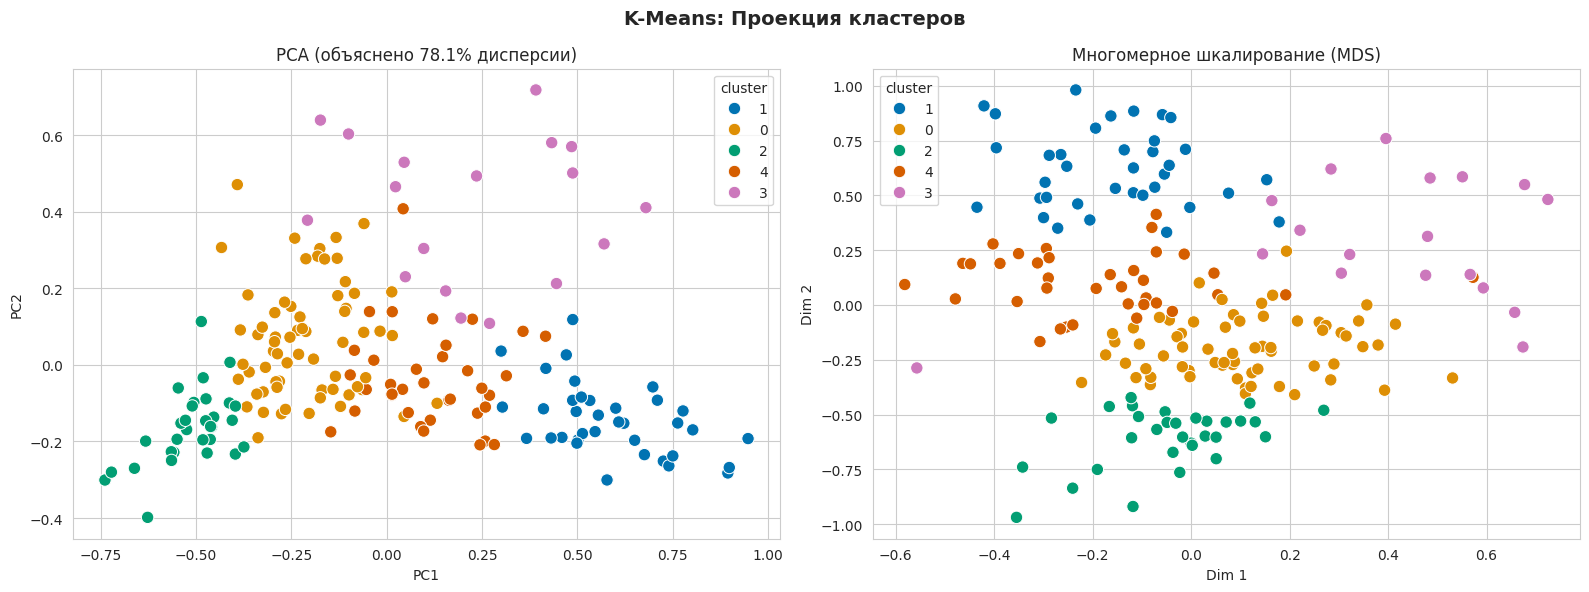

In [ ]:
pca = decomposition.PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_scaled)

df_pca_km = pd.DataFrame({
    "PC1": pca_coords[:, 0],
    "PC2": pca_coords[:, 1],
    "cluster": km_model.labels_.astype(str),
    "country": df.loc[df_cluster.index, "country"].values
})

print(f"\nPCA: \u043e\u0431\u044a\u044f\u0441\u043d\u0451\u043d\u043d\u0430\u044f \u0434\u0438\u0441\u043f\u0435\u0440\u0441\u0438\u044f = {pca.explained_variance_ratio_.sum():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("K-Means: \u041f\u0440\u043e\u0435\u043a\u0446\u0438\u044f \u043a\u043b\u0430\u0441\u0442\u0435\u0440\u043e\u0432", fontsize=14, fontweight="bold")

ax = axes[0]
sns.scatterplot(data=df_pca_km, x="PC1", y="PC2", hue="cluster",
                palette="colorblind", s=80, ax=ax)
ax.set_title(f"PCA (\u043e\u0431\u044a\u044f\u0441\u043d\u0435\u043d\u043e {pca.explained_variance_ratio_.sum():.1%} \u0434\u0438\u0441\u043f\u0435\u0440\u0441\u0438\u0438)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")

mds = MDS(n_components=2, n_init=4, max_iter=300, metric=True, random_state=42, n_jobs=-1)
mds_coords = mds.fit_transform(X_scaled)
df_mds_km = pd.DataFrame({
    "D1": mds_coords[:, 0],
    "D2": mds_coords[:, 1],
    "cluster": km_model.labels_.astype(str),
})

ax = axes[1]
sns.scatterplot(data=df_mds_km, x="D1", y="D2", hue="cluster",
                palette="colorblind", s=80, ax=ax)
ax.set_title("\u041c\u043d\u043e\u0433\u043e\u043c\u0435\u0440\u043d\u043e\u0435 \u0448\u043a\u0430\u043b\u0438\u0440\u043e\u0432\u0430\u043d\u0438\u0435 (MDS)")
ax.set_xlabel("Dim 1")
ax.set_ylabel("Dim 2")

plt.tight_layout()
plt.show()

In [ ]:
print("\n СТРАНЫ ПО КЛАСТЕРАМ (K-MEANS) \n")

for c in sorted(df["cluster_kmeans"].dropna().unique()):
    countries = df.loc[df["cluster_kmeans"] == c, "country"].tolist()
    gdp_mean = df.loc[df["cluster_kmeans"] == c, "GDP per capita (current US$)"].mean()
    urban_mean = df.loc[df["cluster_kmeans"] == c, "Urban population (% of total population)"].mean()

    print(f"КЛАСТЕР {int(c)} (n={len(countries)} стран)")
    print(f"Средний ВВП на душу: ${gdp_mean:,.0f}")
    print(f"Средняя урбанизация: {urban_mean:.1f}%")
    print(f"Страны: {', '.join(countries)}")


=== СТРАНЫ ПО КЛАСТЕРАМ (K-MEANS) ===

КЛАСТЕР 0 (n=65 стран)
Средний ВВП на душу: $11,961
Средняя урбанизация: 58.6%
Страны: Albania, Algeria, Andorra, Angola, Armenia, Azerbaijan, Benin, Bhutan, Bosnia and Herzegovina, Burkina Faso, Cambodia, Cameroon, Central African Republic, Chad, Channel Islands, Chile, China, Hong Kong SAR, China, Macao SAR, China, Congo, Cook Islands, Costa Rica, Cuba, Democratic People's Republic of Korea, Dominican Republic, El Salvador, Estonia, French Guiana, Georgia, Greece, Greenland, Guadeloupe, Haiti, Holy See, Iceland, India, Ireland, Jamaica, Kazakhstan, Kenya, Kiribati, Kuwait, Libya, Lithuania, Malaysia, Mali, Martinique, Mauritius, Mayotte, Montenegro, Montserrat, Myanmar, Nepal, New Caledonia, New Zealand, Nigeria, Niue, Pakistan, Paraguay, Portugal, Saint Helena, Saint Kitts and Nevis, Saint Vincent and the Grenadines, Senegal, Sierra Leone
КЛАСТЕР 1 (n=36 стран)
Средний ВВП на душу: $18,143
Средняя урбанизация: 65.4%
Страны: Afghanistan, America

# МЕТОД DBSCAN

DBSCAN требует задать радиус поиска соседей (eps). Чтобы его подобрать, смотрим на расстояния до 6-го ближайшего соседа для каждой страны. Сортируем эти расстояния и строим график. Там, где график резко идёт вверх — изгиб ("колено") — это хороший кандидат для eps. Компьютер сам находит эту точку методом Kneedle. До колена расстояния маленькие (плотная область), после — начинаются пробелы между точками.

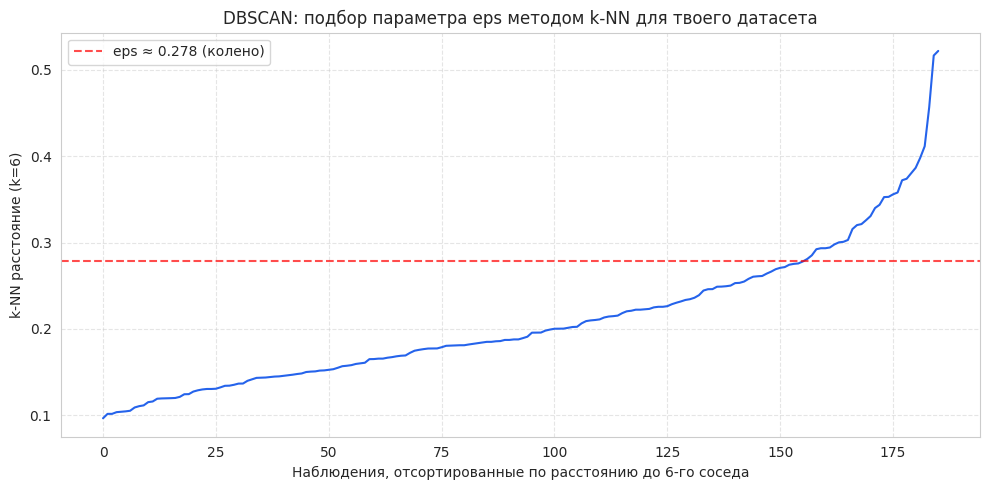

Рекомендуемое значение eps = 0.278
Рекомендуемое значение min_samples = 6


In [ ]:
minPts = 6
nbrs = NearestNeighbors(n_neighbors=minPts).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
sorted_dist = np.sort(distances[:, minPts - 1])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sorted_dist, color="#2563eb")
ax.set_ylabel(f"k-NN расстояние (k={minPts})")
ax.set_xlabel(f"Наблюдения, отсортированные по расстоянию до {minPts}-го соседа")
ax.set_title("DBSCAN: подбор параметра eps методом k-NN для твоего датасета")
ax.grid(True, linestyle="--", alpha=0.5)

def find_knee(y):
    n = len(y)
    x = np.arange(n)
    x_n = (x - x.min()) / (x.max() - x.min())
    y_n = (y - y.min()) / (y.max() - y.min())
    p1 = np.array([x_n[0], y_n[0]])
    p2 = np.array([x_n[-1], y_n[-1]])
    d = np.abs(np.cross(p2 - p1, p1 - np.column_stack([x_n, y_n]))) / np.linalg.norm(p2 - p1)
    return np.argmax(d)

knee_idx = find_knee(sorted_dist)
auto_eps = sorted_dist[knee_idx]
ax.axhline(y=auto_eps, color="red", linestyle="--", alpha=0.7,
           label=f"eps ≈ {auto_eps:.3f} (колено)")
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nРекомендуемое значение eps = {auto_eps:.3f}")
print(f"Рекомендуемое значение min_samples = {minPts}")

Обучаем DBSCAN с найденными eps и min_samples. Алгоритм ищет сгустки точек на карте признаков. Страны в густых скоплениях получают номера кластеров (0, 1, 2...). Те, что затерялись в разреженных зонах, помечаются как шум (-1) — это аномалии или уникальные случаи. Смотрим, сколько получилось кластеров и сколько стран осталось за бортом.

In [ ]:
EPS     = auto_eps
MIN_PTS = minPts

db = DBSCAN(eps=EPS, min_samples=MIN_PTS)
db_labels = db.fit_predict(X_scaled)

dbscan_cluster_series = pd.Series(db_labels, index=df_cluster.index)

df_cluster["cluster_dbscan"] = dbscan_cluster_series.values

unique_labels = np.unique(db_labels)
n_clusters = len(unique_labels[unique_labels != -1])
n_noise    = (db_labels == -1).sum()

print(f"\nПараметры DBSCAN: eps={EPS:.3f}, min_samples={MIN_PTS}")
print(f"Найдено кластеров: {n_clusters}")
print(f"Шумовых точек: {n_noise} ({n_noise / len(db_labels):.1%})")
print(f"\nРаспределение по меткам:")
for lbl in unique_labels:
    tag = "шум" if lbl == -1 else f"кластер {lbl}"
    print(f"  {tag}: {(db_labels == lbl).sum()} наблюдений")

print(f"\n СТРАНЫ-ВЫБРОСЫ (ШУМ)")
noise_countries = df_cluster[df_cluster["cluster_dbscan"] == -1]["country"].tolist()
print(f"Страны в шуме ({len(noise_countries)}): {', '.join(noise_countries)}")

print(f"\n ХАРАКТЕРИСТИКИ КЛАСТЕРОВ DBSCAN")
for lbl in sorted(unique_labels):
    if lbl == -1:
        continue
    cluster_data = df_cluster[df_cluster["cluster_dbscan"] == lbl]
    print(f"\nКластер {lbl} (n={len(cluster_data)}):")
    print(f"  Средний ВВП: ${cluster_data['GDP per capita (current US$)'].mean():,.0f}")
    print(f"  Средняя урбанизация: {cluster_data['Urban population (% of total population)'].mean():.1f}%")
    print(f"  Средняя рождаемость: {cluster_data['Fertility rate, total (live births per woman)'].mean():.2f}")
    print(f"  Примеры стран: {', '.join(cluster_data['country'].head(5).tolist())}")

Параметры DBSCAN: eps=0.278, min_samples=6
Найдено кластеров: 1
Шумовых точек: 12 (6.5%)

Распределение по меткам:
  шум: 12 наблюдений
  кластер 0: 174 наблюдений

 СТРАНЫ-ВЫБРОСЫ (ШУМ)
Страны в шуме (12): Bosnia and Herzegovina, Gabon, Gambia, Lesotho, Luxembourg, Mozambique, Nauru, Saint Lucia, Solomon Islands, State of Palestine, Swaziland, The former Yugoslav Republic of Macedonia

 ХАРАКТЕРИСТИКИ КЛАСТЕРОВ DBSCAN

Кластер 0 (n=174):
  Средний ВВП: $13,127
  Средняя урбанизация: 58.7%
  Средняя рождаемость: 2.84
  Примеры стран: Afghanistan, Albania, Algeria, Angola, Argentina


In [ ]:
minPts = 6

eps_range = np.linspace(0.5, 2.5, 150)

results = []
for eps in eps_range:
    db = DBSCAN(eps=eps, min_samples=minPts)
    labels = db.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    noise_ratio = n_noise / len(labels)

    if n_clusters >= 2 and noise_ratio < 0.9:
        mask = labels != -1
        if mask.sum() > n_clusters:
            sil_score = silhouette_score(X_scaled[mask], labels[mask])
        else:
            sil_score = -1
    else:
        sil_score = -1

    results.append({
        'eps': eps,
        'clusters': n_clusters,
        'noise': n_noise,
        'noise_ratio': noise_ratio,
        'silhouette': sil_score
    })

    if int(eps * 100) % 15 == 0:
        print(f"eps={eps:.3f}: {n_clusters} кластеров, {n_noise} шума ({noise_ratio:.1%}), silhouette={sil_score:.3f}")

results_df = pd.DataFrame(results)

results_df_valid = results_df[(results_df['silhouette'] > 0) & (results_df['noise_ratio'] < 0.5)]
if len(results_df_valid) > 0:
    best_idx = results_df_valid['silhouette'].idxmax()
    EPS = results_df_valid.loc[best_idx, 'eps']
    best_sil = results_df_valid.loc[best_idx, 'silhouette']
    print(f"\n ✅ Лучший eps = {EPS:.3f} (silhouette={best_sil:.3f}, шум={(results_df_valid.loc[best_idx, 'noise_ratio']):.1%})")
else:
    potential_eps_df = results_df[results_df['clusters'] >= 2]
    if len(potential_eps_df) > 0:
        best_idx = potential_eps_df['noise_ratio'].idxmin()
        EPS = potential_eps_df.loc[best_idx, 'eps']
        print(f"\n ✅ Оптимальный eps = {EPS:.3f} (минимальный шум при кластерах)")
    else:

        print("\n ⚠️ Не удалось найти конфигурацию DBSCAN с 2 или более кластерами в заданном диапазоне. Использую eps, дающий минимальный шум (может быть 1 кластер или только шум).")
        best_idx = results_df['noise_ratio'].idxmin()
        EPS = results_df.loc[best_idx, 'eps']
        print(f"\n ✅ Выбран eps = {EPS:.3f} (минимальный шум={(results_df.loc[best_idx, 'noise_ratio']):.1%})")

MIN_PTS = 6

db = DBSCAN(eps=EPS, min_samples=MIN_PTS)
db_labels = db.fit_predict(X_scaled)

dbscan_cluster_series = pd.Series(db_labels, index=df_cluster.index)

df_cluster["cluster_dbscan"] = np.nan

df_cluster.loc[dbscan_cluster_series.index, "cluster_dbscan"] = dbscan_cluster_series.values

print(f"\n=== ИТОГОВАЯ DBSCAN ===")
print(f"eps={EPS:.3f}, min_samples={MIN_PTS}")
print(f"Кластеров: {len(set(db_labels)) - (1 if -1 in db_labels else 0)}")
print(f"Шума: {(db_labels == -1).sum()} ({((db_labels == -1).sum()/len(db_labels)):.1%})")
print(f"\nРаспределение:")
for lbl in sorted(set(db_labels)):
    tag = "шум" if lbl == -1 else f"кластер {lbl}"
    print(f"  {tag}: {(db_labels == lbl).sum()}")

eps=0.607: 1 кластеров, 0 шума (0.0%), silhouette=-1.000
eps=0.755: 1 кластеров, 0 шума (0.0%), silhouette=-1.000
eps=0.903: 1 кластеров, 0 шума (0.0%), silhouette=-1.000
eps=1.050: 1 кластеров, 0 шума (0.0%), silhouette=-1.000
eps=1.359: 1 кластеров, 0 шума (0.0%), silhouette=-1.000
eps=1.507: 1 кластеров, 0 шума (0.0%), silhouette=-1.000
eps=1.654: 1 кластеров, 0 шума (0.0%), silhouette=-1.000
eps=1.802: 1 кластеров, 0 шума (0.0%), silhouette=-1.000
eps=2.258: 1 кластеров, 0 шума (0.0%), silhouette=-1.000
eps=2.406: 1 кластеров, 0 шума (0.0%), silhouette=-1.000

 ⚠️ Не удалось найти конфигурацию DBSCAN с 2 или более кластерами в заданном диапазоне. Использую eps, дающий минимальный шум (может быть 1 кластер или только шум).

 ✅ Выбран eps = 0.500 (минимальный шум=0.0%)

=== ИТОГОВАЯ DBSCAN ===
eps=0.500, min_samples=6
Кластеров: 1
Шума: 0 (0.0%)

Распределение:
  кластер 0: 186


DBSCAN не выявил естественных плотных кластеров в данных — во всём диапазоне параметров все 186 стран объединяются в один кластер. Это свидетельствует о том, что структура данных континуальна (постепенный переход от бедных стран к богатым), а не состоит из изолированных плотных областей. В таких условиях иерархическая кластеризация и K-Means дают более содержательные результаты.

Уникальные метки кластеров и шума, обнаруженные DBSCAN: ['0', 'Шум']
PCA: объяснённая дисперсия = 78.1%
  PC1: 61.1%
  PC2: 17.0%


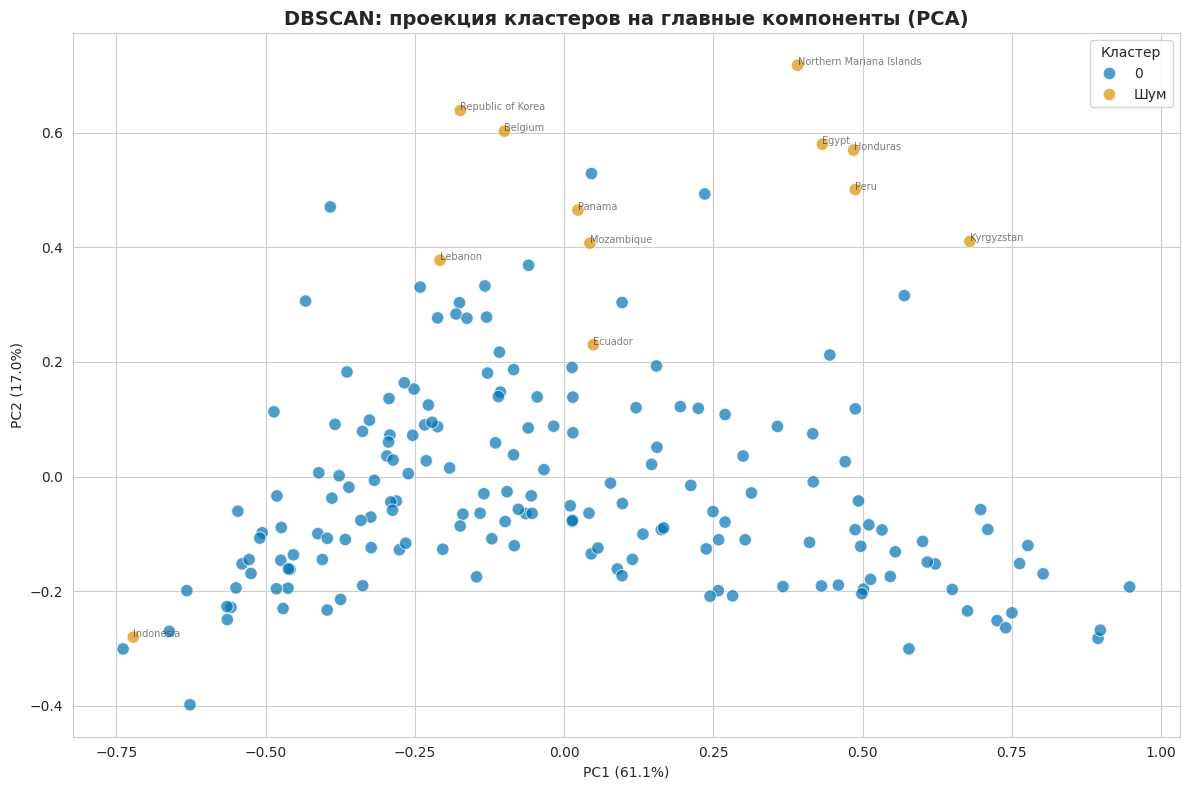

In [ ]:
pca2 = decomposition.PCA(n_components=2, random_state=42)
pca_coords2 = pca2.fit_transform(X_scaled)

df_pca_db = pd.DataFrame({
    "PC1": pca_coords2[:, 0],
    "PC2": pca_coords2[:, 1],
    "cluster": db_labels.astype(str),
    "country": df.loc[df_cluster.index, "country"].values
})

df_pca_db["cluster"] = df_pca_db["cluster"].replace("-1", "Шум")

print(f"\nУникальные метки кластеров и шума, обнаруженные DBSCAN: {sorted(df_pca_db['cluster'].unique().tolist())}")
print(f"PCA: объяснённая дисперсия = {pca2.explained_variance_ratio_.sum():.1%}")
print(f"  PC1: {pca2.explained_variance_ratio_[0]:.1%}")
print(f"  PC2: {pca2.explained_variance_ratio_[1]:.1%}")

fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(data=df_pca_db, x="PC1", y="PC2", hue="cluster",
                palette="colorblind", s=80, alpha=0.7, ax=ax)
ax.set_title("DBSCAN: проекция кластеров на главные компоненты (PCA)", fontsize=14, fontweight="bold")
ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%})")
ax.legend(title="Кластер")
noise_points = df_pca_db[df_pca_db["cluster"] == "Шум"]
for _, row in noise_points.iterrows():
    ax.annotate(row["country"], (row["PC1"], row["PC2"]), fontsize=7, alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
dbscan_cluster_series = pd.Series(db_labels, index=df_cluster.index)
df_cluster["cluster_dbscan"] = dbscan_cluster_series.values

dbscan_means = df_cluster[df_cluster["cluster_dbscan"] != -1].groupby("cluster_dbscan")[clustering_features].mean().round(2)
print("\n СРЕДНИЕ ЗНАЧЕНИЯ ПО КЛАСТЕРАМ DBSCAN (без шума)")
print(dbscan_means.to_string())

dbscan_stds = df_cluster[df_cluster["cluster_dbscan"] != -1].groupby("cluster_dbscan")[clustering_features].std().round(2)
print("\n СТАНДАРТНЫЕ ОТКЛОНЕНИЯ ПО КЛАСТЕРАМ DBSCAN")
print(dbscan_stds.to_string())

print("\n ШУМОВЫЕ ТОЧКИ (ВЫБРОСЫ)")
noise_countries = df_cluster.loc[df_cluster["cluster_dbscan"] == -1, "country"].tolist()
print(f"Всего шумовых точек: {len(noise_countries)}")
print(f"Страны: {', '.join(str(c) for c in noise_countries) if noise_countries else '-'}")

if noise_countries:
    noise_data = df_cluster[df_cluster["cluster_dbscan"] == -1]
    print("\n=== ХАРАКТЕРИСТИКИ СТРАН-ВЫБРОСОВ ===")
    for feat in clustering_features:
        mean_val = noise_data[feat].mean()
        if feat == 'GDP per capita (current US$)':
            print(f"  {feat}: ${mean_val:,.0f} (среднее по всем данным: ${df_cluster[feat].mean():,.0f})")
        else:
            print(f"  {feat}: {mean_val:.2f} (среднее по всем: {df_cluster[feat].mean():.2f})")

print("\n=== СРАВНЕНИЕ КЛАСТЕРОВ DBSCAN ===")
for cluster in sorted(dbscan_means.index):
    cluster_data = df_cluster[df_cluster["cluster_dbscan"] == cluster]
    print(f"\nКластер {cluster} (n={len(cluster_data)} стран):")
    print(f"  ВВП на душу: ${cluster_data['GDP per capita (current US$)'].mean():,.0f}")
    print(f"  Урбанизация: {cluster_data['Urban population (% of total population)'].mean():.1f}%")
    print(f"  Рождаемость: {cluster_data['Fertility rate, total (live births per woman)'].mean():.2f}")
    print(f"  Детская смертность: {cluster_data['Infant mortality rate (per 1000 live births)'].mean():.1f}")
    print(f"  Безработица: {cluster_data['Unemployment (% of labour force)'].mean():.1f}%")
    print(f"  Примеры стран: {', '.join(cluster_data['country'].head(5).tolist())}")

 СРЕДНИЕ ЗНАЧЕНИЯ ПО КЛАСТЕРАМ DBSCAN (без шума)
                GDP per capita (current US$)  Urban population (% of total population)  Fertility rate, total (live births per woman)  Infant mortality rate (per 1000 live births)  Unemployment (% of labour force)
cluster_dbscan                                                                                                                                                                                                       
0                                   13126.61                                     58.74                                           2.84                                         25.54                              7.74

 СТАНДАРТНЫЕ ОТКЛОНЕНИЯ ПО КЛАСТЕРАМ DBSCAN
                GDP per capita (current US$)  Urban population (% of total population)  Fertility rate, total (live births per woman)  Infant mortality rate (per 1000 live births)  Unemployment (% of labour force)
cluster_dbscan                                    

  СРАВНЕНИЕ K-MEANS, DBSCAN И ИЕРАРХИЧЕСКОЙ КЛАСТЕРИЗАЦИИ

PCA объясняет 78.1% дисперсии
  PC1: 61.1%
  PC2: 17.0%


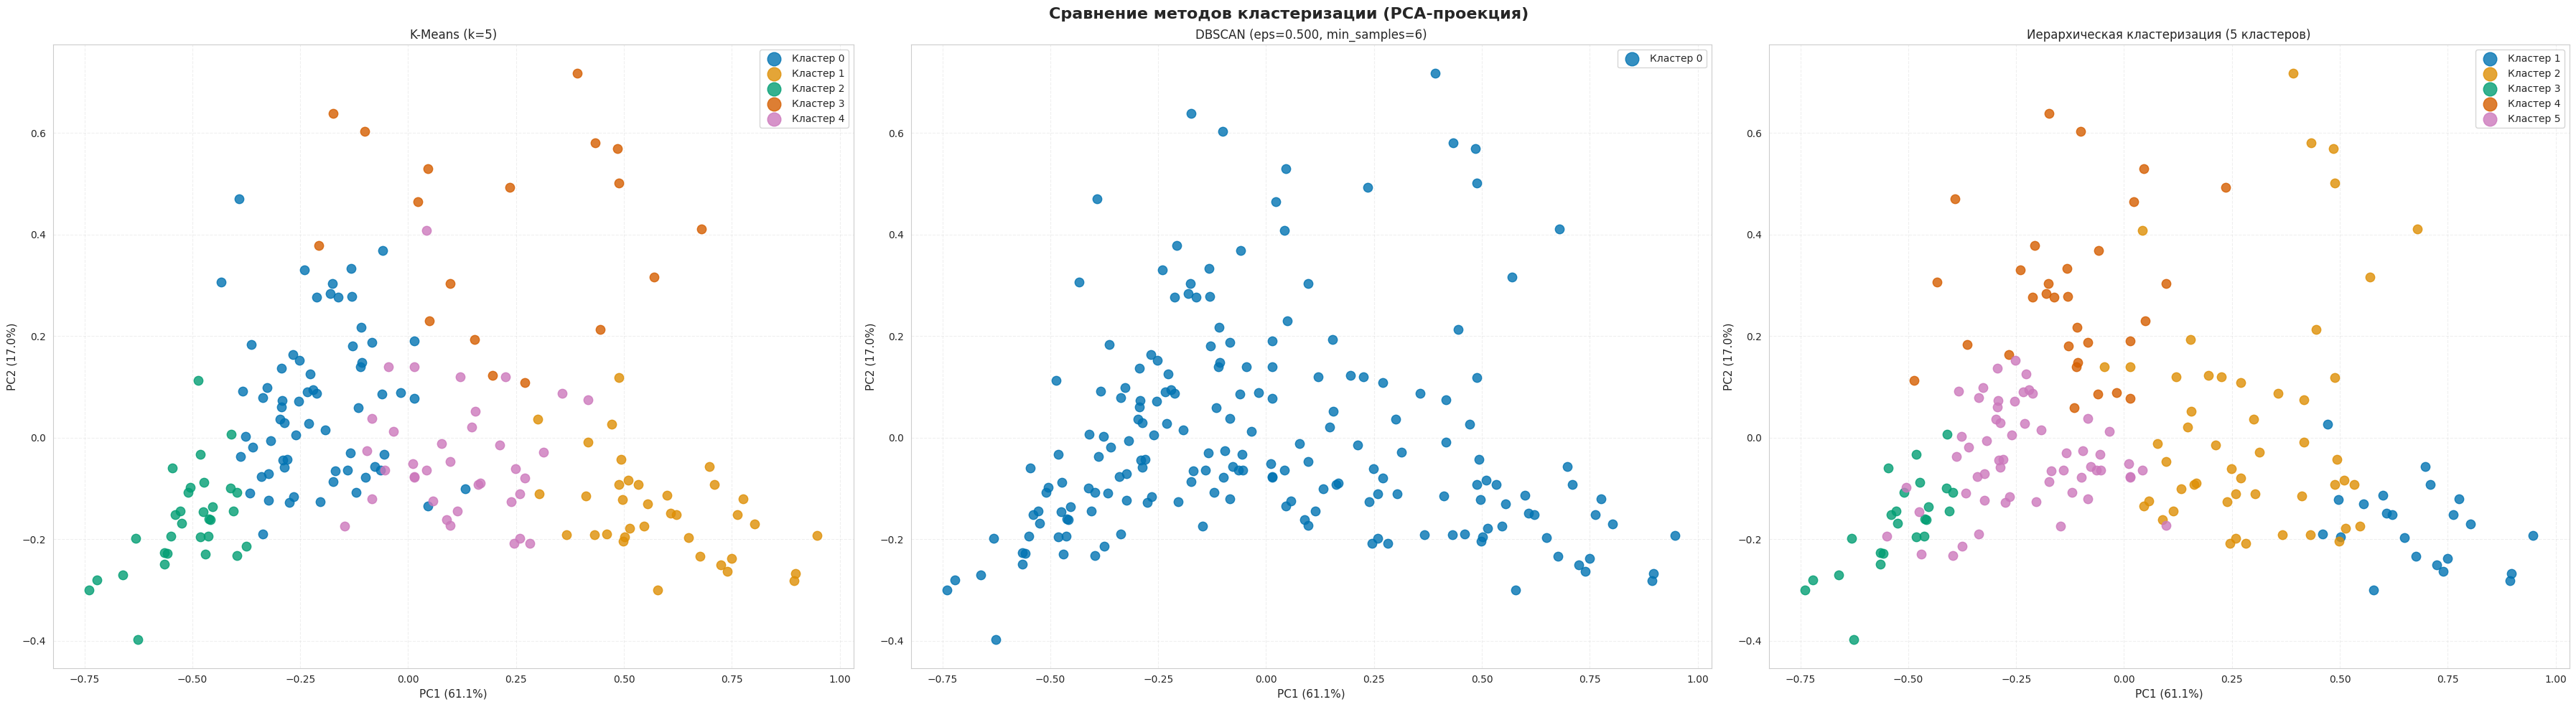

=== СРАВНЕНИЕ МЕТРИК КАЧЕСТВА ===

Метод                     Silhouette   Calinski-Harabasz  Davies-Bouldin 
----------------------------------------------------------------------
K-Means                   0.307        114                1.057          
DBSCAN (без шума)         -1.000       -1                 -1.000         
Иерархический             0.244        94                 1.185          


In [ ]:
# Сравнение K-Means, DBSCAN и иерархической кластеризации
print("  СРАВНЕНИЕ K-MEANS, DBSCAN И ИЕРАРХИЧЕСКОЙ КЛАСТЕРИЗАЦИИ")


fig, axes = plt.subplots(1, 3, figsize=(36, 10))
fig.suptitle("Сравнение методов кластеризации (PCA-проекция)", fontsize=16, fontweight="bold")

# PCA на тех же данных
pca3 = decomposition.PCA(n_components=2, random_state=42).fit(X_scaled)
coords = pca3.transform(X_scaled)

# Объяснённая дисперсия
print(f"\nPCA объясняет {pca3.explained_variance_ratio_.sum():.1%} дисперсии")
print(f"  PC1: {pca3.explained_variance_ratio_[0]:.1%}")
print(f"  PC2: {pca3.explained_variance_ratio_[1]:.1%}")

# 1. K-Means
ax = axes[0]
unique = np.unique(km_model.labels_)
palette = sns.color_palette("colorblind", len(unique))
for lbl, color in zip(unique, palette):
    mask = km_model.labels_ == lbl
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=[color], label=f"Кластер {lbl}", s=80, marker="o", alpha=0.8)
ax.set_title(f"K-Means (k={OPTIMAL_K})", fontsize=12)
ax.set_xlabel(f"PC1 ({pca3.explained_variance_ratio_[0]:.1%})", fontsize=11)
ax.set_ylabel(f"PC2 ({pca3.explained_variance_ratio_[1]:.1%})", fontsize=11)
ax.legend(markerscale=1.5, fontsize=10, loc='best')
ax.grid(True, linestyle="--", alpha=0.3)

# 2. DBSCAN
ax = axes[1]
unique = np.unique(db_labels)
palette = sns.color_palette("colorblind", len(unique))
for lbl, color in zip(unique, palette):
    mask = db_labels == lbl
    name = "шум" if lbl == -1 else f"Кластер {lbl}"
    marker = "x" if lbl == -1 else "o"
    size = 120 if lbl == -1 else 80
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=[color], label=name, s=size, marker=marker, alpha=0.8)
ax.set_title(f"DBSCAN (eps={EPS:.3f}, min_samples={MIN_PTS})", fontsize=12)
ax.set_xlabel(f"PC1 ({pca3.explained_variance_ratio_[0]:.1%})", fontsize=11)
ax.set_ylabel(f"PC2 ({pca3.explained_variance_ratio_[1]:.1%})", fontsize=11)
ax.legend(markerscale=1.5, fontsize=10, loc='best')
ax.grid(True, linestyle="--", alpha=0.3)

# 3. Иерархический анализ
ax = axes[2]
# Используем df_clean['cluster'] (уже должна быть)
hier_labels = cluster_series.values
unique_hier = np.unique(hier_labels)
palette_hier = sns.color_palette("colorblind", len(unique_hier))
for lbl, color in zip(unique_hier, palette_hier):
    mask = hier_labels == lbl
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=[color], label=f"Кластер {lbl}", s=80, marker="o", alpha=0.8)
ax.set_title("Иерархическая кластеризация (5 кластеров)", fontsize=12)
ax.set_xlabel(f"PC1 ({pca3.explained_variance_ratio_[0]:.1%})", fontsize=11)
ax.set_ylabel(f"PC2 ({pca3.explained_variance_ratio_[1]:.1%})", fontsize=11)
ax.legend(markerscale=1.5, fontsize=10, loc='best')
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# Сравнение метрик качества
print("\n=== СРАВНЕНИЕ МЕТРИК КАЧЕСТВА ===")
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# K-Means
km_sil = silhouette_score(X_scaled, km_model.labels_)
km_ch = calinski_harabasz_score(X_scaled, km_model.labels_)
km_db = davies_bouldin_score(X_scaled, km_model.labels_)

# DBSCAN (только не-шум)
db_mask = db_labels != -1
if db_mask.sum() > 1 and len(set(db_labels[db_mask])) > 1:
    db_sil = silhouette_score(X_scaled[db_mask], db_labels[db_mask])
    db_ch = calinski_harabasz_score(X_scaled[db_mask], db_labels[db_mask])
    db_db = davies_bouldin_score(X_scaled[db_mask], db_labels[db_mask])
else:
    db_sil, db_ch, db_db = -1, -1, -1

# Иерархия
hier_sil = silhouette_score(X_scaled, hier_labels)
hier_ch = calinski_harabasz_score(X_scaled, hier_labels)
hier_db = davies_bouldin_score(X_scaled, hier_labels)

print(f"\n{'Метод':<25} {'Silhouette':<12} {'Calinski-Harabasz':<18} {'Davies-Bouldin':<15}")
print("-" * 70)
print(f"{'K-Means':<25} {km_sil:<12.3f} {km_ch:<18.0f} {km_db:<15.3f}")
print(f"{'DBSCAN (без шума)':<25} {db_sil:<12.3f} {db_ch:<18.0f} {db_db:<15.3f}")
print(f"{'Иерархический':<25} {hier_sil:<12.3f} {hier_ch:<18.0f} {hier_db:<15.3f}")
